# Hybrid Transformer Architecture for Context-Aware Phishing Email Classification
## Phase 2 — Model Training, Cross-Source Evaluation & Statistical Robustness

**Corpus:** MEPC — Multi-source Email Phishing Corpus
**Prerequisite:** Phase 1 (`Thesis_Phase1_EDA_Preprocessing.ipynb`) run to completion.

**How to run:** `Runtime → Change runtime type → T4 GPU`, then `Runtime → Run all`.
Every heavy step is cached to Drive. If Colab disconnects, simply **Run all again**: finished
encoders, embeddings and baselines are reloaded, and an interrupted fine-tune resumes from its
last completed epoch.

| Part | Content |
|---|---|
| A | Environment, data, **all split designs (A, B, C1–C3)**, integrity audit, source–class confound audit |
| B | Tokenisation, tokenizer coverage per language, data loaders |
| C | DistilBERT fine-tuning (shared trainer, runs until early stopping fires) |
| D | DistilBERT evaluation on every protocol |
| E | Embedding extraction (one encoder per design) |
| F | MLP heads: embeddings-only (ablation reference) and embeddings + structural (fusion) |
| G | Classical and CNN baselines, refitted on every protocol |
| H | Unified comparison, generalisation gap, per-language evaluability |
| I | Statistical robustness: all-seed tables, grouped CV, bootstrap CIs, McNemar tests |
| J | Operating-point selection (validation only) |
| K | Persistence, hyperparameter table, thesis tables, summary |

**Reviewer comments addressed in the code**

| Reviewer | Comment | Where |
|---|---|---|
| R1.1 | Split B confounds source and class | A6 builds leave-one-source-out folds C1–C3 (each held-out TREC source has both classes) and audits every held-out source's class composition |
| R1.3 | Robustness only shown in-distribution | I1 seeds on **every** protocol; I3 bootstrap CIs; cross-source mean ± SD over C1–C3 |
| R1.4 | Training budget still binding | C: 20-epoch budget, patience 3; C4 audits whether early stopping actually fired |
| R1.5 | Reproducibility details missing | K: versions, GPU, full hyperparameters, run signatures, split files saved |
| R3.2 | Which models/splits were cross-validated? | I2 states and tables it explicitly |
| R3.3 | "Ordering preserved across every seed" needs a table | I1 per-seed table plus an explicit ordering check |
| R3.4 | Is the ablation "text-only" the fine-tuned DistilBERT? | F trains an explicit embeddings-only head, reported separately from DistilBERT (text-only) |
| R4 | Imbalance handling, hyperparameters, multilingual clarity, curve readability | A6 class weights; K hyperparameter table; B2 tokenizer coverage; C3 redrawn curves |

---
# PART A — ENVIRONMENT, DATA, SPLIT DESIGNS
---

In [1]:
# A1 — Imports. transformers is only installed if missing, which avoids the forced
# runtime restart that wiped session state in the previous version.
import importlib.util, subprocess, sys
if importlib.util.find_spec('transformers') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'transformers'], check=True)

import os, re, gc, json, time, math, hashlib, platform, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy
import scipy.sparse as sp
from scipy.stats import binomtest

import sklearn
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix, roc_auc_score,
                             average_precision_score)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)

warnings.filterwarnings('ignore')
transformers.logging.set_verbosity_error()

VERSIONS = {'python': platform.python_version(), 'torch': torch.__version__,
            'transformers': transformers.__version__, 'sklearn': sklearn.__version__,
            'numpy': np.__version__, 'pandas': pd.__version__, 'scipy': scipy.__version__}
print(VERSIONS)

{'python': '3.13.15', 'torch': '2.11.0+cu128', 'transformers': '5.16.1', 'sklearn': '1.6.1', 'numpy': '2.1.3', 'pandas': '2.2.3', 'scipy': '1.16.3'}


In [2]:
# A2 — RUN CONFIGURATION. Every setting that changes a result lives here.
SEED = 42

# Set True for a ~10-minute smoke test on tiny subsamples. Outputs go to Thesis/quicktest/
# so a smoke test can never overwrite or be mistaken for the real run.
QUICK_TEST = False

MODEL_CHECKPOINT = 'distilbert-base-uncased'   # English encoder (see B2 for coverage of other languages)
EMBED_DIM = 768

# Fine-tuning (identical for every design). Implements Reviewer 1, comment 4 literally:
# "either extend the maximum number of epochs until early stopping actually occurs, or
# provide empirical evidence that validation F1 has reached a plateau." train_until_plateau()
# in Part C starts at EPOCHS and, if neither condition is met, extends by EPOCH_INCREMENT
# up to MAX_EPOCH_CEILING.
EPOCHS               = 10
EARLY_STOP_PATIENCE  = 3
EPOCH_INCREMENT      = 5      # how much to extend the budget by if still genuinely improving
MAX_EPOCH_CEILING     = 25    # hard stop regardless, to keep this time-bounded
PLATEAU_TOLERANCE    = 0.0015 # if val F1 moves less than this over the last (patience+1)
                               # epochs, treat that as empirical plateau evidence even if
                               # literal early stopping (no_improve >= patience) never fires

LEARNING_RATE       = 2e-5      # DistilBERT
CNN_LEARNING_RATE   = 1e-3      # CNN trained from scratch needs a larger step size
WEIGHT_DECAY        = 0.01
WARMUP_RATIO        = 0.10      # linear warmup over the first 10% of steps
MAX_GRAD_NORM       = 1.0

# Shorter than the original 256: table_tokenizer_language_coverage (B2) shows truncation
# rates well below 256 for most languages, so this cuts real per-epoch cost with a
# defensible, reportable trade-off rather than an arbitrary one.
MAX_LEN = 192

# MLP heads on frozen embeddings
HEAD_HIDDEN, HEAD_DROPOUT = (256, 64), 0.2
HEAD_LR, HEAD_BATCH, HEAD_MAX_EPOCHS, HEAD_PATIENCE = 1e-3, 256, 100, 10

# Classical baselines
TFIDF_PARAMS = dict(max_features=50000, ngram_range=(1, 2), min_df=3, max_df=0.95,
                    sublinear_tf=True, strip_accents='unicode', dtype=np.float32)
TEXT_CHAR_LIMIT = 5000          # bounds TF-IDF memory on very long bodies

# Robustness
HEAD_SEEDS          = [42, 43, 44, 45, 46]   # cheap: heads train on frozen embeddings in <1s each
CV_FOLDS            = 5
RUN_CLASSICAL_CV    = False     # OFF by default: refitting the full classical suite x5 folds
                                 # is one of the most expensive things in the notebook after
                                 # DistilBERT fine-tuning. Stability for classical models is
                                 # instead reported via I1 (5-seed) and the grouped head CV in
                                 # I2a. Flip True only for a final, dedicated overnight run.
REPLICATE_RF_ACROSS_SEEDS  = True   # cheap (seconds per fit) — refit RF per seed
REPLICATE_SVM_ACROSS_SEEDS = True   # cheap: LinearSVC's random_state drives real seed variance
CV_HEAD_DESIGNS = ['A', 'B']        # which designs get their own held-out-pool fold-CV in I2a
                                     # (closes the earlier gap where only Split A had a CV table)
N_BOOTSTRAP         = 1000      # cheap: pure numpy over already-computed predictions
EXTRA_ENCODER_SEEDS = []        # leave empty: re-fine-tuning DistilBERT per seed costs hours each

SAVE_FUSION_ARRAYS_FOR = ['A', 'B', 'C1', 'C2', 'C3']   # 781-dim arrays for Phase 3

# Run Part C for ONE design per Colab session. The checkpoint/resume logic in C1 makes this
# safe: re-running with the same or a higher epoch budget resumes rather than restarting.
DESIGNS_THIS_SESSION = None   # set e.g. ['A'] when training; leave None for the final
                               # aggregation session once all five encoders are trained

if QUICK_TEST:
    EPOCHS, EARLY_STOP_PATIENCE = 2, 1
    HEAD_SEEDS, N_BOOTSTRAP, QUICK_N = [42, 43], 100, 400


def set_seed(s):
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)


set_seed(SEED)
print(f'QUICK_TEST={QUICK_TEST} | checkpoint={MODEL_CHECKPOINT} | start_epochs={EPOCHS} '
      f'| patience={EARLY_STOP_PATIENCE} | ceiling={MAX_EPOCH_CEILING} | max_len={MAX_LEN} '
      f'| classical_cv={RUN_CLASSICAL_CV} | rf_seed_replicate={REPLICATE_RF_ACROSS_SEEDS} '
      f'| svm_seed_replicate={REPLICATE_SVM_ACROSS_SEEDS} | cv_head_designs={CV_HEAD_DESIGNS} '
      f'| designs_this_session={DESIGNS_THIS_SESSION}')

QUICK_TEST=False | checkpoint=distilbert-base-uncased | start_epochs=10 | patience=3 | ceiling=25 | max_len=192 | classical_cv=False | rf_seed_replicate=True | svm_seed_replicate=True | cv_head_designs=['A', 'B'] | designs_this_session=None


In [3]:
# A3 — Drive and paths
from google.colab import drive
drive.mount('/content/drive')

ROOT      = '/content/drive/MyDrive/Thesis/'
PREP_DIR  = ROOT + 'preprocessed/'                 # Phase 1 inputs (read)
OUT_ROOT  = ROOT + ('quicktest/' if QUICK_TEST else '')
OUT_DIR   = OUT_ROOT + 'preprocessed/'             # Phase 2 outputs (== PREP_DIR in a real run)
MODEL_DIR = OUT_ROOT + 'models/'
BASE_DIR  = MODEL_DIR + 'baselines/'
FIG_DIR   = OUT_ROOT + 'figures/'
TABLE_DIR = OUT_ROOT + 'tables/'
CACHE_DIR = ROOT + 'cache/'                        # tokenisation cache is safe to share

for d in (OUT_DIR, MODEL_DIR, BASE_DIR, FIG_DIR, TABLE_DIR, CACHE_DIR):
    os.makedirs(d, exist_ok=True)

REQUIRED = ['mepc_clean.parquet', 'config.json', 'scaler_A.pkl', 'scaler_B.pkl']
missing = [f for f in REQUIRED if not os.path.exists(PREP_DIR + f)]
assert not missing, f'Missing Phase 1 artefacts: {missing}. Run Phase 1 to completion first.'
print('Phase 1 artefacts found. Outputs ->', OUT_ROOT)


def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name))
    print(f'  figure saved: {name}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Phase 1 artefacts found. Outputs -> /content/drive/MyDrive/Thesis/


In [4]:
# A4 — Phase 1 config, palette, style
with open(PREP_DIR + 'config.json') as f:
    config = json.load(f)

pal = config['palette']
AMBER, AMBER_D, AMBER_L = pal['AMBER'], pal['AMBER_D'], pal['AMBER_L']
GRAPHITE, SLATE         = pal['GRAPHITE'], pal['SLATE']
PHISH, LEGIT, PAPER     = pal['PHISH'], pal['LEGIT'], pal['PAPER']
SEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    'mepc_seq', [PAPER, AMBER_L, AMBER, AMBER_D, GRAPHITE])

# Distinct, colour-blind-safe colours for designs (Reviewer 4: curve/legend readability)
DESIGN_COLORS = {'A': '#E69F00', 'B': '#D55E00', 'C1': '#0072B2', 'C2': '#009E73', 'C3': '#CC79A7'}

mpl.rcParams.update({
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER, 'savefig.facecolor': PAPER,
    'axes.edgecolor': GRAPHITE, 'axes.labelcolor': GRAPHITE, 'axes.linewidth': 0.9,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#D8D5CC', 'grid.linewidth': 0.6,
    'text.color': GRAPHITE, 'xtick.color': GRAPHITE, 'ytick.color': GRAPHITE,
    'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.titlesize': 12,
    'axes.titleweight': 'bold', 'legend.frameon': False, 'figure.dpi': 110,
    'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False})

STRUCT_FEATURES = config['struct_features']
N_STRUCT        = len(STRUCT_FEATURES)
MAX_LEN         = config['max_len']
HELD_OUT_SRC    = config['held_out_source']
ROTATING_FOLDS  = config.get('rotating_folds', {'C1': 'trec5', 'C2': 'trec6', 'C3': 'trec7'})
PARTS = ['train', 'val', 'test']

print(f'Structural features ({N_STRUCT}): {STRUCT_FEATURES}')
print(f'max_len {MAX_LEN} | Split B held-out source: {HELD_OUT_SRC} | rotating folds: {ROTATING_FOLDS}')

Structural features (13): ['url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'uppercase_ratio', 'punct_density', 'digit_count', 'currency_flag', 'html_flag', 'body_length', 'subject_length', 'attachment_count']
max_len 256 | Split B held-out source: phishing_pot | rotating folds: {'C1': 'trec5', 'C2': 'trec6', 'C3': 'trec7'}


In [5]:
# A5 — Corpus, Split A/B arrays, column detection, structural-scaling verification
t0 = time.time()
df = pd.read_parquet(PREP_DIR + 'mepc_clean.parquet')
assert df.index.is_unique, 'df.index must be unique'
assert df['label'].isin([0, 1]).all()
print(f'Corpus: {len(df):,} rows x {df.shape[1]} cols ({time.time() - t0:.1f}s)')


def pick_col(candidates, what, check=lambda c: True, required=True):
    for c in candidates:
        if c in df.columns and check(c):
            return c
    if required:
        raise KeyError(f'Could not find the {what} column. Tried {candidates}. '
                       f'Columns available: {list(df.columns)}')
    return None


SOURCE_COL = pick_col(['source', 'src', 'corpus', 'origin', 'dataset', 'source_corpus'],
                      'source', check=lambda c: (df[c] == HELD_OUT_SRC).any())
GROUP_COL  = pick_col(['dup_group', 'campaign_group', 'dup_group_id', 'group_id'], 'duplicate-group')
LANG_COL   = pick_col(['lang', 'language', 'primary_lang', 'primary_language', 'lang_primary',
                       'detected_lang', 'lg'], 'language', required=False)
print(f'source column: {SOURCE_COL} | group column: {GROUP_COL} | language column: {LANG_COL}')

scaler_A = joblib.load(PREP_DIR + 'scaler_A.pkl')

split_arrays = {}
for design in ['A', 'B']:
    for part in PARTS:
        Xp = f'{PREP_DIR}X_struct_{design}_{part}.npy'
        if os.path.exists(Xp):
            split_arrays[(design, part)] = (np.load(Xp).astype(np.float32),
                                            np.load(f'{PREP_DIR}y_{design}_{part}.npy').astype(np.int64),
                                            np.load(f'{PREP_DIR}idx_{design}_{part}.npy'))
for k, (X, y, idx) in split_arrays.items():
    assert X.shape[1] == N_STRUCT and len(X) == len(y) == len(idx), k
    assert np.array_equal(df.loc[idx, 'label'].to_numpy().astype(np.int64), y), f'{k}: labels disagree with df'

# Work out exactly how Phase 1 turned raw structural columns into the saved arrays, so the
# rotating folds built below are scaled the same way (fitted on their own training data only).
STRUCT_TRANSFORMS = {'identity': lambda a: a,
                     'log1p': lambda a: np.log1p(np.clip(a, 0, None))}
_XA, _, _idxA = split_arrays[('A', 'train')]
_raw = df.loc[_idxA[:5000], STRUCT_FEATURES].astype('float64').fillna(0).to_numpy()
STRUCT_TRANSFORM, STRUCT_VERIFIED = 'identity', False
for _name, _fn in STRUCT_TRANSFORMS.items():
    try:
        if np.allclose(scaler_A.transform(_fn(_raw)), _XA[:5000], atol=1e-3):
            STRUCT_TRANSFORM, STRUCT_VERIFIED = _name, True
            break
    except Exception:
        pass
if STRUCT_VERIFIED:
    print(f'Phase 1 structural scaling reproduced exactly: {STRUCT_TRANSFORM} + {type(scaler_A).__name__}')
else:
    print('WARNING: could not reproduce Phase 1 scaling exactly; rotating folds use '
          'StandardScaler on raw features.')


def struct_matrix(rows, fit_rows):
    """Scaled structural features for `rows`, scaler fitted on `fit_rows` only."""
    fn = STRUCT_TRANSFORMS[STRUCT_TRANSFORM]
    raw = lambda r: fn(df.loc[r, STRUCT_FEATURES].astype('float64').fillna(0).to_numpy())
    scaler = clone(scaler_A) if STRUCT_VERIFIED else StandardScaler()
    scaler.fit(raw(fit_rows))
    return scaler.transform(raw(rows)).astype(np.float32)


# Extended structural set for the random-forest baseline (Phase 1 names it in config if present)
EXT_FEATURES = list(STRUCT_FEATURES)
for _k, _v in config.items():
    if (isinstance(_v, list) and _v and all(isinstance(x, str) and x in df.columns for x in _v)
            and ('ext' in _k.lower() or set(STRUCT_FEATURES) <= set(_v)) and _k != 'struct_features'):
        EXT_FEATURES = list(dict.fromkeys(EXT_FEATURES + _v))
print(f'Random-forest feature set: {len(EXT_FEATURES)} features')

Corpus: 99,707 rows x 34 cols (2.1s)
source column: source | group column: dup_group | language column: lang_primary
Phase 1 structural scaling reproduced exactly: identity + StandardScaler
Random-forest feature set: 13 features


In [6]:
# A6 — Rotating leave-one-source-out folds, integrity assertions, confound audit
#
# Reviewer 1, comment 1: in Split B the held-out source (phishing_pot) is 100% phishing, so
# "unseen source" and "phishing class" are the same thing. Folds C1-C3 each withhold one TREC
# collection, which contains BOTH classes, so a drop in performance there cannot be a class effect.
FOLD_ORIGIN = {}
for d, held in ROTATING_FOLDS.items():
    col = f'split_{d}'
    if col in df.columns and set(df[col].dropna().unique()) >= {'train', 'val', 'test'}:
        FOLD_ORIGIN[d] = 'Phase 1'
    else:
        FOLD_ORIGIN[d] = 'built in Phase 2'
        is_test = df[SOURCE_COL] == held
        assert is_test.any(), f'{d}: source {held!r} not found in {SOURCE_COL}'
        test_groups = set(df.loc[is_test, GROUP_COL])
        pool = df.index[~is_test & ~df[GROUP_COL].isin(test_groups)]
        n_dropped = int((~is_test).sum() - len(pool))
        sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
        tr_pos, va_pos = next(sgkf.split(np.zeros(len(pool)), df.loc[pool, 'label'],
                                         df.loc[pool, GROUP_COL]))
        s = pd.Series('excluded', index=df.index, dtype=object)
        s.loc[is_test[is_test].index] = 'test'
        s.loc[pool[tr_pos]] = 'train'
        s.loc[pool[va_pos]] = 'val'
        df[col] = s
        print(f'{d}: held out {held}; {n_dropped} rows dropped because their duplicate group '
              f'also occurs in the held-out source')
    for part in PARTS:
        rows = df.index[df[col] == part].to_numpy()
        X = struct_matrix(rows, df.index[df[col] == 'train'])
        split_arrays[(d, part)] = (X, df.loc[rows, 'label'].to_numpy().astype(np.int64), rows)

if any(v == 'built in Phase 2' for v in FOLD_ORIGIN.values()):
    df[[f'split_{d}' for d in ROTATING_FOLDS]].to_parquet(OUT_DIR + 'splits_rotating.parquet')
    print('Rotating split assignments saved to splits_rotating.parquet (reuse these in Phase 3)')

DESIGNS = [d for d in ['A', 'B'] + list(ROTATING_FOLDS) if all((d, p) in split_arrays for p in PARTS)]
LOSO_DESIGNS = [d for d in ROTATING_FOLDS if d in DESIGNS]
HELD = {d: ROTATING_FOLDS.get(d, HELD_OUT_SRC if d == 'B' else 'none') for d in DESIGNS}

# ── Integrity assertions (halt on failure) ──────────────────────────────
audit_rows = []
for d in DESIGNS:
    sets = {p: set(split_arrays[(d, p)][2]) for p in PARTS}
    grp = {p: set(df.loc[list(sets[p]), GROUP_COL]) for p in PARTS}
    assert not (sets['train'] & sets['test']) and not (sets['train'] & sets['val']) \
        and not (sets['val'] & sets['test']), f'{d}: partitions overlap'
    assert not (grp['train'] & grp['test']), f'{d}: a duplicate group spans train and test'
    for p in PARTS:
        assert len(set(split_arrays[(d, p)][1])) == 2, f'{d}/{p}: a class is missing'
    if d != 'A':
        seen = df.loc[list(sets['train'] | sets['val']), SOURCE_COL]
        assert not (seen == HELD[d]).any(), f'{d}: held-out source leaks into train/val'
    else:
        assert len(sets['train'] | sets['val'] | sets['test']) == len(df), 'A: incomplete assignment'
    audit_rows.append({'design': d, 'held_out': HELD[d], 'origin': FOLD_ORIGIN.get(d, 'Phase 1'),
                       'train': len(sets['train']), 'val': len(sets['val']), 'test': len(sets['test']),
                       'groups_train_and_val': len(grp['train'] & grp['val'])})
print('\nAll integrity assertions passed.')
print(pd.DataFrame(audit_rows).to_string(index=False))

# ── Source x class composition of every partition ───────────────────────
comp = []
for d in DESIGNS:
    for p in PARTS:
        sub = df.loc[split_arrays[(d, p)][2]]
        for src, g in sub.groupby(SOURCE_COL):
            comp.append({'design': d, 'part': p, 'source': src, 'n': len(g),
                         'phishing': int(g['label'].sum()), 'phishing_pct': round(g['label'].mean() * 100, 1)})
comp_df = pd.DataFrame(comp)
comp_df.to_csv(OUT_DIR + 'table_split_composition.csv', index=False)

confound = []
for d in DESIGNS:
    if d == 'A':
        continue
    held_rows = df[df[SOURCE_COL] == HELD[d]]
    confound.append({'design': d, 'held_out_source': HELD[d], 'n': len(held_rows),
                     'legitimate': int((held_rows['label'] == 0).sum()),
                     'phishing': int(held_rows['label'].sum()),
                     'source_class_confounded': held_rows['label'].nunique() == 1})
confound_df = pd.DataFrame(confound)
confound_df.to_csv(OUT_DIR + 'table_heldout_source_confound.csv', index=False)
print('\n=== HELD-OUT SOURCE CLASS COMPOSITION (Reviewer 1, comment 1) ===')
print(confound_df.to_string(index=False))

# ── Class weights from each design's own training labels (Reviewer 4: imbalance) ──
CLASS_WEIGHTS = {}
for d in DESIGNS:
    y = split_arrays[(d, 'train')][1]
    CLASS_WEIGHTS[d] = [len(y) / (2 * (y == 0).sum()), len(y) / (2 * (y == 1).sum())]
    print(f'  {d}: class weights legitimate {CLASS_WEIGHTS[d][0]:.4f} | phishing {CLASS_WEIGHTS[d][1]:.4f}')

if QUICK_TEST:
    rng = np.random.default_rng(SEED)
    for k, (X, y, idx) in list(split_arrays.items()):
        keep = np.sort(np.concatenate([rng.choice(np.where(y == c)[0], min(QUICK_N // 2, (y == c).sum()),
                                                  replace=False) for c in (0, 1)]))
        split_arrays[k] = (X[keep], y[keep], idx[keep])
    print(f'\n*** QUICK_TEST: every partition subsampled to <= {QUICK_N} rows ***')
print(f'\nDesigns: {DESIGNS}')


All integrity assertions passed.
design     held_out  origin  train  val  test  groups_train_and_val
     A         none Phase 1  71789 7976 19942                     0
     B phishing_pot Phase 1  79633 8849 11225                     0
    C1        trec5 Phase 1  50818 5647 43242                     0
    C2        trec6 Phase 1  77215 8580 13912                     0
    C3        trec7 Phase 1  55479 6165 38063                     0

=== HELD-OUT SOURCE CLASS COMPOSITION (Reviewer 1, comment 1) ===
design held_out_source     n  legitimate  phishing  source_class_confounded
     B    phishing_pot  4490           0      4490                     True
    C1           trec5 43242       26394     16848                    False
    C2           trec6 13912       11087      2825                    False
    C3           trec7 38063       18614     19449                    False
  A: class weights legitimate 0.8887 | phishing 1.1431
  B: class weights legitimate 0.8963 | phishing 1.1309
 

In [7]:
# A7 — Device (batch size only; the epoch budget/extension logic is set in A2 and Part C)
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    GPU_NAME = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    USE_FP16 = True
    BATCH_SIZE = 32 if gpu_mem >= 10 else 16
    print(f'GPU: {GPU_NAME} ({gpu_mem:.1f} GB) | batch {BATCH_SIZE} | fp16')
else:
    DEVICE, GPU_NAME, USE_FP16, BATCH_SIZE = torch.device('cpu'), 'cpu', False, 8
    print('No GPU attached.')

# Fine-tuning a transformer on CPU will not finish inside a reasonable session and is almost
# always the real cause of "timeout" errors. Fail fast here instead of discovering it hours
# into Part C.
if DEVICE.type != 'cuda' and not QUICK_TEST:
    raise RuntimeError(
        "No GPU detected. Go to Runtime -> Change runtime type -> T4 GPU, then "
        "Runtime -> Restart session and run all again. (Set QUICK_TEST = True in A2 "
        "if you only want to smoke-test the pipeline on CPU.)"
    )

GPU: Tesla T4 (14.6 GB) | batch 32 | fp16


---
# PART B — TOKENISATION, LANGUAGE COVERAGE, LOADERS
---

In [8]:
# B1 — Tokenizer and cached tokenisation of the whole corpus
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
TOK_CACHE = CACHE_DIR + f"tokenised_{MODEL_CHECKPOINT.replace('/', '_')}_{MAX_LEN}.pt"
LEGACY_TOK_CACHE = CACHE_DIR + 'tokenised_full.pt'   # written by the previous notebook version


def _valid_cache(c):
    return (c['input_ids'].shape == (len(df), MAX_LEN)
            and np.array_equal(np.asarray(c['index']), df.index.to_numpy()))


cached = None
for path in [TOK_CACHE] + ([LEGACY_TOK_CACHE] if MODEL_CHECKPOINT == 'distilbert-base-uncased' else []):
    if os.path.exists(path):
        c = torch.load(path, weights_only=False)
        if _valid_cache(c):
            cached = c
            print(f'Tokenisation loaded from cache: {os.path.basename(path)}')
            break
if cached is None:
    t0 = time.time()
    print(f'Tokenising {len(df):,} emails at max_len={MAX_LEN} ...')
    enc = tokenizer(df['text'].fillna('').tolist(), max_length=MAX_LEN, padding='max_length',
                    truncation=True, return_tensors='pt')
    cached = {'input_ids': enc['input_ids'].to(torch.int32),
              'attention_mask': enc['attention_mask'].to(torch.uint8),
              'index': df.index.to_numpy(), 'checkpoint': MODEL_CHECKPOINT, 'max_len': MAX_LEN}
    torch.save(cached, TOK_CACHE)
    print(f'Tokenised and cached in {time.time() - t0:.0f}s')

input_ids, attention_mask = cached['input_ids'], cached['attention_mask']   # compact int32 / uint8
pos_of = pd.Series(np.arange(len(df)), index=df.index)
del cached
gc.collect()
print(f'Token tensor {tuple(input_ids.shape)}')

Tokenisation loaded from cache: tokenised_full.pt
Token tensor (99707, 256)


In [9]:
# B2 — How the English tokenizer treats each language (Reviewer 4: multilingual clarity)
#
# distilbert-base-uncased has an English WordPiece vocabulary. Non-English text is still
# encoded (it is never dropped), but it fragments into more sub-word pieces and more [UNK]s.
# This table quantifies that, so the thesis can state precisely what "retained" means.
if LANG_COL is None:
    print('No language column in the corpus; skipping.')
    lang_cov_df = pd.DataFrame()
else:
    unk_id = tokenizer.unk_token_id
    n_real = attention_mask.sum(dim=1).numpy()
    n_unk = (input_ids == unk_id).sum(dim=1).numpy()
    truncated = attention_mask[:, -1].numpy() == 1
    rows = []
    rng = np.random.default_rng(SEED)
    for lang, g in df.groupby(LANG_COL):
        if len(g) < 50:
            continue
        p = pos_of.loc[g.index].to_numpy()
        sample = g['text'].fillna('').iloc[rng.permutation(len(g))[:200]].str.slice(0, 2000).tolist()
        words = sum(len(t.split()) for t in sample)
        pieces = sum(len(tokenizer.tokenize(t)) for t in sample)
        rows.append({'language': lang, 'n': len(g), 'phishing_pct': round(g['label'].mean() * 100, 1),
                     'legitimate': int((g['label'] == 0).sum()),
                     'unk_rate_pct': round(n_unk[p].sum() / max(n_real[p].sum(), 1) * 100, 2),
                     'wordpieces_per_word': round(pieces / max(words, 1), 2),
                     'truncated_at_max_len_pct': round(truncated[p].mean() * 100, 1)})
    lang_cov_df = pd.DataFrame(rows).sort_values('n', ascending=False)
    lang_cov_df.to_csv(OUT_DIR + 'table_tokenizer_language_coverage.csv', index=False)
    print('=== TOKENIZER COVERAGE BY LANGUAGE (languages with >= 50 emails) ===\n')
    print(lang_cov_df.to_string(index=False))

=== TOKENIZER COVERAGE BY LANGUAGE (languages with >= 50 emails) ===

language     n  phishing_pct  legitimate  unk_rate_pct  wordpieces_per_word  truncated_at_max_len_pct
      en 93905          40.5       55902          0.01                 1.79                      44.0
      de  1333          97.3          36          0.26                 2.84                      55.4
      ru   770          99.4           5          0.47                16.40                      54.3
      pt   697          98.1          13          0.12                 2.44                      56.1
      ja   464          97.6          11          0.15                21.38                      60.8
      fr   410          90.0          41          0.22                 2.63                      43.9
      es   401          93.3          27          0.06                 3.18                      44.6
      zh   339          98.8           4          0.14                24.23                      56.6
      nl   2

In [10]:
# B3 — Dataset and loaders. Tokens stay int32/uint8 in memory and are cast per item,
# which keeps RAM low enough that five designs do not crash the Colab runtime.
class EmailDataset(Dataset):
    def __init__(self, row_idx, labels):
        pos = torch.as_tensor(pos_of.loc[row_idx].to_numpy())
        self.ids, self.mask = input_ids[pos], attention_mask[pos]
        self.labels = torch.as_tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {'input_ids': self.ids[i].long(), 'attention_mask': self.mask[i].long(),
                'labels': self.labels[i]}


def make_loader(design, part, batch_size, shuffle, seed=SEED):
    _, y, idx = split_arrays[(design, part)]
    gen = torch.Generator().manual_seed(seed) if shuffle else None
    return DataLoader(EmailDataset(idx, y), batch_size=batch_size, shuffle=shuffle,
                      generator=gen, num_workers=2, pin_memory=DEVICE.type == 'cuda')


for d in DESIGNS:
    print(f'Split {d:<3} held out: {HELD[d]:<13} '
          + '  '.join(f'{p} {len(split_arrays[(d, p)][2]):>6,}' for p in PARTS))

print('\nContamination audit (why each design gets its own encoder):')
for d in DESIGNS[1:]:
    t = df.loc[split_arrays[(d, 'test')][2]]
    leak = int((t['split_A'] == 'train').sum())
    print(f'  {leak:,} of {len(t):,} {d}-test emails ({leak / len(t) * 100:.1f}%) are in Split A train.')

Split A   held out: none          train 71,789  val  7,976  test 19,942
Split B   held out: phishing_pot  train 79,633  val  8,849  test 11,225
Split C1  held out: trec5         train 50,818  val  5,647  test 43,242
Split C2  held out: trec6         train 77,215  val  8,580  test 13,912
Split C3  held out: trec7         train 55,479  val  6,165  test 38,063

Contamination audit (why each design gets its own encoder):
  8,043 of 11,225 B-test emails (71.7%) are in Split A train.
  31,134 of 43,242 C1-test emails (72.0%) are in Split A train.
  10,017 of 13,912 C2-test emails (72.0%) are in Split A train.
  27,405 of 38,063 C3-test emails (72.0%) are in Split A train.


---
# PART C — DISTILBERT FINE-TUNING

One encoder per design, all trained by the **same** `train_classifier` function (also used for
the CNN in Part G). The epoch budget is 20 with patience 3 on validation F1, so training ends
when validation F1 stops improving rather than when the budget runs out (Reviewer 1, comment 4).
C4 checks whether that actually happened.

Each epoch is checkpointed with a **run signature** (budget, learning rate, warmup, batch size,
seed, training size). A checkpoint is resumed only when its signature matches the current
configuration. A stale checkpoint from an earlier configuration is discarded automatically, and
a matching one is never deleted, so re-running after a disconnect resumes instead of restarting.

**Expected time on a T4:** about 8–12 min per epoch per design. Five designs usually need
5–10 epochs each before early stopping, which comes to roughly 4–8 hours in total, spread over
several sessions if needed.

In [11]:
# C0 — Standalone setup for Part C
import os, gc, json, time, random, glob, re
import numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

from google.colab import drive
drive.mount('/content/drive')

# ================= OPTIONAL OVERRIDES (leave as None for auto) =================
# Hardcoded to the known Phase 1 output path. This skips the recursive glob.glob('**/*')
# over the whole of Google Drive that the auto-search fallback below performs, which is
# itself a common, silent source of long hangs before Part C even starts.
CORPUS_PATH = '/content/drive/MyDrive/Thesis/preprocessed/mepc_clean.parquet'
SEARCH_ROOT = '/content/drive/MyDrive'
HELD_OUT_SOURCE = 'phishing_pot'

SEED = globals().get('SEED', 42)
EPOCHS = globals().get('EPOCHS', 10)
EARLY_STOP_PATIENCE = globals().get('EARLY_STOP_PATIENCE', 3)
EPOCH_INCREMENT = globals().get('EPOCH_INCREMENT', 5)
MAX_EPOCH_CEILING = globals().get('MAX_EPOCH_CEILING', 25)
PLATEAU_TOLERANCE = globals().get('PLATEAU_TOLERANCE', 0.0015)
BATCH_SIZE = globals().get('BATCH_SIZE', 16)
MAX_LEN = globals().get('MAX_LEN', 192)
WARMUP_RATIO, WEIGHT_DECAY, MAX_GRAD_NORM = 0.1, 0.01, 1.0
MODEL_CHECKPOINT = globals().get('MODEL_CHECKPOINT', 'distilbert-base-uncased')
QUICK_TEST = globals().get('QUICK_TEST', False)
# ===============================================================================

CANDS = {
    'label':   ['label', 'is_phishing', 'is_spam', 'y', 'target', 'class', 'spam', 'phishing'],
    'text':    ['text', 'clean_text', 'email_text', 'text_clean', 'content', 'message'],
    'body':    ['body', 'body_text', 'email_body', 'clean_body'],
    'subject': ['subject', 'email_subject'],
    'group':   ['dup_group', 'group', 'campaign_group', 'dup_id', 'group_id'],
    'source':  ['source', 'corpus', 'origin', 'dataset', 'source_corpus', 'collection'],
}

def find_col(cols, key):
    low = {c.lower(): c for c in cols}
    for name in CANDS[key]:
        if name in low:
            return low[name]
    return None

def load_table(path):
    if path.endswith('.parquet'):
        return pd.read_parquet(path)
    return pd.read_csv(path, low_memory=False, encoding_errors='ignore')

# ---------- 1. Locate the corpus (no Drive-wide search when CORPUS_PATH is set) ----------
if CORPUS_PATH is None:
    print('CORPUS_PATH not set — searching Drive for the corpus (can take a while)...')
    def read_columns(path):
        try:
            if path.endswith('.parquet'):
                import pyarrow.parquet as pq
                return pq.read_schema(path).names
            return pd.read_csv(path, nrows=3, encoding_errors='ignore').columns.tolist()
        except Exception:
            return []
    files = []
    for ext in ('csv', 'parquet'):
        files += glob.glob(f'{SEARCH_ROOT}/**/*.{ext}', recursive=True)
    files = [f for f in files if os.path.getsize(f) > 5e6]
    best, best_score = None, -1
    for f in sorted(files, key=os.path.getsize, reverse=True):
        cols = read_columns(f)
        if not cols or not find_col(cols, 'label') or not (find_col(cols, 'text') or find_col(cols, 'body')):
            continue
        score = 3 + 2 * bool(find_col(cols, 'group')) + 2 * bool(find_col(cols, 'source'))
        score += 1 * any(re.search(r'(split|design)', c, re.I) for c in cols)
        if score > best_score:
            best, best_score = f, score
    if best is None:
        raise FileNotFoundError('No file with label + text columns found. Set CORPUS_PATH manually.')
    CORPUS_PATH = best
assert os.path.exists(CORPUS_PATH), f'CORPUS_PATH does not exist: {CORPUS_PATH}'
print('Corpus file:', CORPUS_PATH)

PROJECT_DIR = os.path.dirname(CORPUS_PATH) + '/'
MODEL_DIR = PROJECT_DIR + 'models/'
SPLIT_FILE = PROJECT_DIR + 'split_assignments_partC.csv'
os.makedirs(MODEL_DIR, exist_ok=True)

# ---------- 2. Load and detect columns ----------
df = load_table(CORPUS_PATH).reset_index(drop=True)
cols = df.columns.tolist()
LABEL_COL, TEXT_COL = find_col(cols, 'label'), find_col(cols, 'text')
BODY_COL, SUBJ_COL = find_col(cols, 'body'), find_col(cols, 'subject')
GROUP_COL, SOURCE_COL = find_col(cols, 'group'), find_col(cols, 'source')
print(f'Columns -> label: {LABEL_COL} | text: {TEXT_COL} | body: {BODY_COL} | subject: {SUBJ_COL} '
      f'| group: {GROUP_COL} | source: {SOURCE_COL}')
print(f'Rows: {len(df):,}')

if TEXT_COL is None:
    subj = df[SUBJ_COL].fillna('').astype(str) + ' ' if SUBJ_COL else ''
    df['text'] = subj + df[BODY_COL].fillna('').astype(str)
    TEXT_COL = 'text'
df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)

lab = df[LABEL_COL]
if lab.dtype == object or lab.dtype == bool:
    lab = lab.astype(str).str.strip().str.lower().map(
        lambda s: 1 if s.startswith(('phish', 'spam', 'true', '1')) else 0)
df['y'] = lab.astype(int)
print('Class counts:', df['y'].value_counts().to_dict())

if GROUP_COL is None:
    print('WARNING: no dup_group column found; each email treated as its own group.')
    df['dup_group'] = np.arange(len(df)); GROUP_COL = 'dup_group'

if SOURCE_COL is not None:
    vals = df[SOURCE_COL].astype(str).unique()

# Restrict which designs Part C will actually train this session, per DESIGNS_THIS_SESSION
# in A2. Running all five encoders back-to-back is what causes multi-hour sessions that Colab
# kills. Run one design per session — C1's checkpoint/resume logic supports this safely.
_requested = globals().get('DESIGNS_THIS_SESSION', None)
if _requested:
    DESIGNS = [d for d in _requested if d in (globals().get('DESIGNS') or ['A', 'B', 'C1', 'C2', 'C3'])]
    print(f'DESIGNS_THIS_SESSION set: training only {DESIGNS} this session.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Corpus file: /content/drive/MyDrive/Thesis/preprocessed/mepc_clean.parquet
Columns -> label: label | text: text | body: body | subject: subject | group: dup_group | source: source
Rows: 99,707
Class counts: {0: 56095, 1: 43612}


In [12]:
# C1 — Shared trainer with auto-extending epoch budget (Reviewer 1, comment 4)
def forward_logits(model, ids, attn):
    out = model(input_ids=ids, attention_mask=attn)
    return out.logits if hasattr(out, 'logits') else out


def run_epoch(model, loader, loss_fn, opt=None, sch=None, scl=None):
    train = opt is not None
    model.train(train)
    total, preds, labels = 0.0, [], []
    for batch in loader:
        ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        attn = batch['attention_mask'].to(DEVICE, non_blocking=True)
        y = batch['labels'].to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(train), torch.amp.autocast(DEVICE.type, enabled=USE_FP16):
            logits = forward_logits(model, ids, attn)
            loss = loss_fn(logits.float(), y)
        if train:
            opt.zero_grad(set_to_none=True)
            scl.scale(loss).backward()
            scl.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scl.step(opt)
            scl.update()
            sch.step()
        total += loss.item() * len(y)
        preds.append(logits.argmax(1).cpu())
        labels.append(y.cpu())
    p, l = torch.cat(preds).numpy(), torch.cat(labels).numpy()
    return {'loss': total / len(l), 'f1': f1_score(l, p, zero_division=0), 'acc': accuracy_score(l, p)}


def atomic_save(obj, path):
    torch.save(obj, path + '.tmp')
    os.replace(path + '.tmp', path)


def load_ckpt(path):
    if not os.path.exists(path):
        return None
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except Exception as e:
        print(f'  {os.path.basename(path)} unreadable ({e}); ignoring it.')
        return None


def train_classifier(tag, design, build_model, lr, epoch_budget, seed=SEED):
    """Fine-tune / train one model on one design up to `epoch_budget` epochs, with resume support.

    `epoch_budget` is deliberately NOT part of the checkpoint signature, so calling this again
    with a HIGHER budget resumes and continues training rather than restarting from scratch.
    Only genuine early stopping (no_improve >= patience) marks the run 'finished' inside this
    function; hitting the current epoch_budget just pauses the loop so train_until_plateau()
    can decide whether to extend it, treat it as plateaued, or stop at the ceiling.
    """
    suffix = '' if seed == SEED else f'_s{seed}'
    ckpt_path = f'{MODEL_DIR}{tag}_ckpt_{design}{suffix}.pt'
    best_path = f'{MODEL_DIR}{tag}_best_{design}{suffix}.pt'
    train_loader = make_loader(design, 'train', BATCH_SIZE, shuffle=True, seed=seed)
    val_loader = make_loader(design, 'val', BATCH_SIZE * 2, shuffle=False)
    sig = {'tag': tag, 'design': design, 'checkpoint': MODEL_CHECKPOINT,
           'patience': EARLY_STOP_PATIENCE, 'lr': lr, 'warmup': WARMUP_RATIO,
           'weight_decay': WEIGHT_DECAY, 'batch': BATCH_SIZE, 'max_len': MAX_LEN, 'seed': seed,
           'n_train': len(train_loader.dataset), 'quick_test': QUICK_TEST}

    set_seed(seed)
    model = build_model().to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    state = {'history': [], 'best_val_f1': -1.0, 'best_epoch': 0, 'no_improve': 0,
             'next_epoch': 0, 'finished': False, 'stopped_early': False,
             'plateau_evidence': False, 'signature': sig, 'n_params': n_params}

    state_path = f'{MODEL_DIR}{tag}_state_{design}{suffix}.json'
    saved = json.load(open(state_path)) if os.path.exists(state_path) else None
    ckpt = None
    if saved and saved.get('signature') == sig:
        state = saved
        if state['finished'] and os.path.exists(best_path):
            print(f'  [{tag}/{design}{suffix}] already finished '
                  f"({len(state['history'])} epochs, best val F1 {state['best_val_f1']:.4f}).")
        else:
            ckpt = load_ckpt(ckpt_path)
            if ckpt is not None and ckpt.get('signature') == sig:
                print(f"  [{tag}/{design}{suffix}] resuming at epoch {state['next_epoch'] + 1}, "
                      f"target budget {epoch_budget}")
            else:
                ckpt = None
    else:
        if os.path.exists(ckpt_path) or os.path.exists(best_path):
            print(f'  [{tag}/{design}{suffix}] discarding checkpoint from a different configuration.')
            for p in (ckpt_path, best_path):
                if os.path.exists(p):
                    os.remove(p)

    if not state['finished'] and state['next_epoch'] < epoch_budget:
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        n_steps = len(train_loader) * epoch_budget
        sch = get_linear_schedule_with_warmup(opt, int(n_steps * WARMUP_RATIO), n_steps)
        scl = torch.amp.GradScaler(DEVICE.type, enabled=USE_FP16)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(CLASS_WEIGHTS[design],
                                                          dtype=torch.float32, device=DEVICE))
        if ckpt is not None:
            model.load_state_dict(ckpt['model_state'])
            opt.load_state_dict(ckpt['optimizer_state'])
            sch.load_state_dict(ckpt['scheduler_state'])
            scl.load_state_dict(ckpt['scaler_state'])
        del ckpt
        gc.collect()

        for epoch in range(state['next_epoch'], epoch_budget):
            t_ep = time.time()
            tr = run_epoch(model, train_loader, loss_fn, opt, sch, scl)
            va = run_epoch(model, val_loader, loss_fn)
            dt = time.time() - t_ep
            state['history'].append({'design': design, 'seed': seed, 'epoch': epoch + 1,
                                     'lr_end': sch.get_last_lr()[0], 'train_loss': tr['loss'],
                                     'train_f1': tr['f1'], 'val_loss': va['loss'],
                                     'val_f1': va['f1'], 'val_acc': va['acc'], 'seconds': dt})
            msg = (f"  [{tag}/{design}{suffix}] epoch {epoch + 1} (budget {epoch_budget})  "
                   f"train loss {tr['loss']:.4f}  | val loss {va['loss']:.4f} F1 {va['f1']:.4f} "
                   f"acc {va['acc']:.4f}  ({dt:.0f}s)")
            if va['f1'] > state['best_val_f1']:
                state.update(best_val_f1=va['f1'], best_epoch=epoch + 1, no_improve=0)
                atomic_save({'model_state': model.state_dict(), 'signature': sig,
                             'epoch': epoch + 1, 'val_f1': va['f1']}, best_path)
                msg += '  <- best'
            else:
                state['no_improve'] += 1
                msg += f"  (no improvement {state['no_improve']}/{EARLY_STOP_PATIENCE})"
            print(msg)
            state['next_epoch'] = epoch + 1
            if state['no_improve'] >= EARLY_STOP_PATIENCE:
                state['stopped_early'] = state['finished'] = True   # genuine early stop
            atomic_save({'model_state': model.state_dict(), 'optimizer_state': opt.state_dict(),
                         'scheduler_state': sch.state_dict(), 'scaler_state': scl.state_dict(),
                         'state': state, 'signature': sig}, ckpt_path)
            with open(state_path, 'w') as fh:
                json.dump(state, fh, default=float)
            if state['finished']:
                break
            # Reaching epoch_budget without no_improve firing does NOT set finished=True.
            # The loop just ends; train_until_plateau() decides whether to extend, treat as
            # plateaued, or stop at the ceiling.
        del opt, sch, scl

    best = load_ckpt(best_path)
    if best is None or best.get('signature') != sig:
        raise RuntimeError(f'Best checkpoint {best_path} missing or stale; delete {ckpt_path} and re-run.')
    model.load_state_dict(best['model_state'])
    model.eval().cpu()
    del best
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    return model, state


def train_until_plateau(tag, design, build_model, lr, seed=SEED):
    """Implements Reviewer 1, comment 4 directly: extend the epoch budget until early
    stopping genuinely fires, OR stop once validation F1 has empirically plateaued
    (near-zero movement over the last patience+1 epochs), OR hit a hard ceiling.
    Whichever applies is recorded in state['stop_reason'] so it can be reported honestly
    in the thesis rather than assumed.
    """
    budget = EPOCHS
    while True:
        model, state = train_classifier(tag, design, build_model, lr, epoch_budget=budget, seed=seed)
        if state['stopped_early']:
            print(f'  [{tag}/{design}] genuine early stopping fired at epoch {state["best_epoch"]} '
                  f'(final budget {budget}).')
            return model, state

        h = pd.DataFrame(state['history'])
        tail = h['val_f1'].tail(EARLY_STOP_PATIENCE + 1)
        f1_range = float(tail.max() - tail.min()) if len(tail) == EARLY_STOP_PATIENCE + 1 else np.inf

        if f1_range < PLATEAU_TOLERANCE:
            state['plateau_evidence'], state['finished'] = True, True
            print(f'  [{tag}/{design}] no literal early stop, but val F1 moved only '
                  f'{f1_range:.5f} over the last {EARLY_STOP_PATIENCE + 1} epochs '
                  f'(< tolerance {PLATEAU_TOLERANCE}) -> empirically plateaued at epoch '
                  f'{len(h)} (budget {budget}).')
            return model, state

        if budget >= MAX_EPOCH_CEILING:
            state['plateau_evidence'], state['finished'] = False, True
            print(f'  [{tag}/{design}] reached hard ceiling {MAX_EPOCH_CEILING} epochs without '
                  f'early stopping or a clear plateau (val F1 range {f1_range:.5f}). Stopping; '
                  f'report as a residual limitation for this design.')
            return model, state

        new_budget = min(budget + EPOCH_INCREMENT, MAX_EPOCH_CEILING)
        print(f'  [{tag}/{design}] still meaningfully improving (val F1 range {f1_range:.5f} '
              f'>= tolerance) and no early stop yet -> extending budget {budget} -> {new_budget}.')
        budget = new_budget


DESIGNS = ['A', 'B']
HELD = {'A': 'none (in-distribution)', 'B': globals().get('HELD_OUT_SOURCE', 'phishing_pot')}
LEARNING_RATE = 2e-5
OUT_DIR = globals().get('PROJECT_DIR', '/content/drive/MyDrive/') + 'outputs/'
os.makedirs(OUT_DIR, exist_ok=True)
print('Designs:', DESIGNS, '| held out:', HELD, '| LR:', LEARNING_RATE, '| outputs ->', OUT_DIR)

Designs: ['A', 'B'] | held out: {'A': 'none (in-distribution)', 'B': 'phishing_pot'} | LR: 2e-05 | outputs -> /content/drive/MyDrive/Thesis/preprocessed/outputs/


In [13]:
# C2 — Fine-tune one DistilBERT encoder per design, extending the epoch budget
def build_distilbert():
    return AutoModelForSequenceClassification.from_pretrained(MODEL_CHECKPOINT, num_labels=2)


encoders, enc_states = {}, {}
for d in DESIGNS:
    print(f"\n{'=' * 70}\n  DISTILBERT — SPLIT {d} (held out: {HELD[d]})\n{'=' * 70}")
    encoders[d], enc_states[d] = train_until_plateau('distilbert', d, build_distilbert, LEARNING_RATE)

hist_df = pd.DataFrame([h for d in DESIGNS for h in enc_states[d]['history']])
hist_df.to_csv(OUT_DIR + 'table_distilbert_history.csv', index=False)
print('\nEpochs run per design:', {d: len(enc_states[d]['history']) for d in DESIGNS})
print('Stop reason per design:',
      {d: ('early_stopping_fired' if enc_states[d]['stopped_early']
           else 'empirical_plateau' if enc_states[d].get('plateau_evidence')
           else 'max_ceiling_reached') for d in DESIGNS})


  DISTILBERT — SPLIT A (held out: none (in-distribution))


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  [distilbert/A] already finished (9 epochs, best val F1 0.9880).
  [distilbert/A] genuine early stopping fired at epoch 6 (final budget 10).

  DISTILBERT — SPLIT B (held out: phishing_pot)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

  [distilbert/B] already finished (6 epochs, best val F1 0.9874).
  [distilbert/B] genuine early stopping fired at epoch 3 (final budget 10).

Epochs run per design: {'A': 9, 'B': 6}
Stop reason per design: {'A': 'early_stopping_fired', 'B': 'early_stopping_fired'}


  figure saved: f25_distilbert_training_curves.png


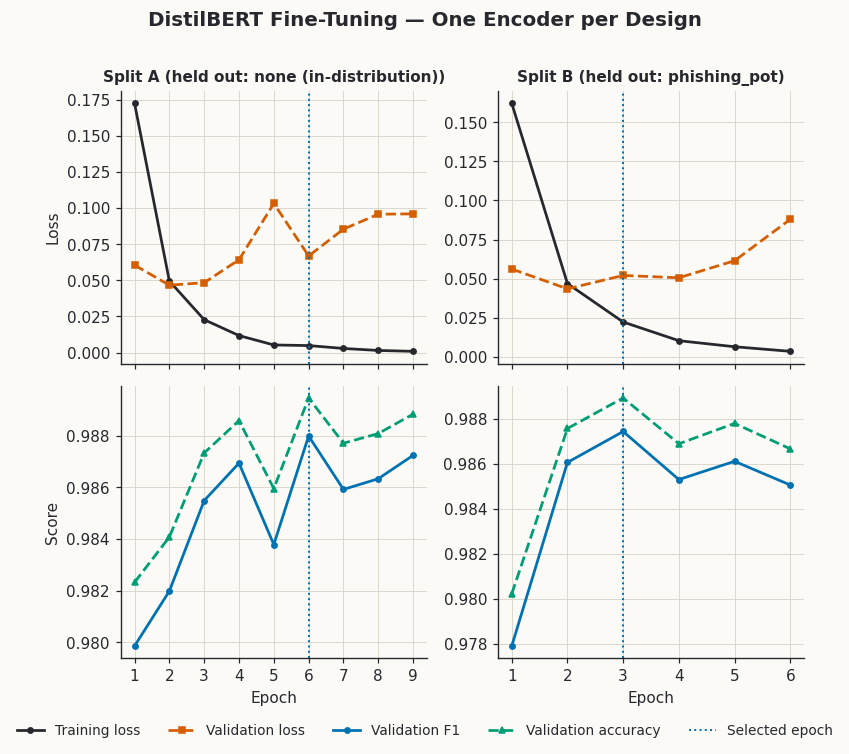

In [14]:
# C3 — Training curves: one column per design, loss on top, validation F1/accuracy below.
# Separate panels and fixed colours replace the overlapping lines of the earlier figure (Reviewer 4).
def plot_training_curves(states, title, fname):
    ds = list(states)
    fig, axes = plt.subplots(2, len(ds), figsize=(3.6 * len(ds), 6.4), squeeze=False, sharex='col')
    for j, d in enumerate(ds):
        h = pd.DataFrame(states[d]['history'])
        if h.empty:
            continue
        ax = axes[0, j]
        ax.plot(h['epoch'], h['train_loss'], '-o', color=GRAPHITE, ms=3.5, lw=1.8, label='Training loss')
        ax.plot(h['epoch'], h['val_loss'], '--s', color='#D55E00', ms=3.5, lw=1.8, label='Validation loss')
        ax.set_title(f'Split {d} (held out: {HELD[d]})', fontsize=10)
        ax.axvline(states[d]['best_epoch'], color='#0072B2', ls=':', lw=1.3)
        ax = axes[1, j]
        ax.plot(h['epoch'], h['val_f1'], '-o', color='#0072B2', ms=3.5, lw=1.8, label='Validation F1')
        ax.plot(h['epoch'], h['val_acc'], '--^', color='#009E73', ms=3.5, lw=1.8, label='Validation accuracy')
        ax.axvline(states[d]['best_epoch'], color='#0072B2', ls=':', lw=1.3, label='Selected epoch')
        ax.set_xlabel('Epoch')
        ax.set_xticks(h['epoch'])
        if j == 0:
            axes[0, j].set_ylabel('Loss')
            axes[1, j].set_ylabel('Score')
    handles = axes[0, 0].get_legend_handles_labels()[0] + axes[1, 0].get_legend_handles_labels()[0]
    labels = axes[0, 0].get_legend_handles_labels()[1] + axes[1, 0].get_legend_handles_labels()[1]
    fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.04), fontsize=9)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    fig.tight_layout()
    savefig(fig, fname)
    plt.show()


plot_training_curves(enc_states, 'DistilBERT Fine-Tuning — One Encoder per Design',
                     'f25_distilbert_training_curves.png')

In [15]:
# C4 — Did early stopping fire, or is there empirical plateau evidence? (Reviewer 1, comment 4)
def stopping_audit(states, tag):
    rows = []
    for d, st in states.items():
        h = pd.DataFrame(st['history'])
        tail = h['val_f1'].tail(EARLY_STOP_PATIENCE + 1)
        reason = ('early_stopping_fired' if st['stopped_early']
                  else 'empirical_plateau' if st.get('plateau_evidence')
                  else 'max_ceiling_reached')
        rows.append({'model': tag, 'design': d, 'epochs_run': len(h), 'final_epoch_budget': len(h),
                     'best_epoch': st['best_epoch'], 'best_val_f1': round(st['best_val_f1'], 4),
                     'stop_reason': reason,
                     'epochs_after_best': len(h) - st['best_epoch'],
                     f'val_f1_range_last_{EARLY_STOP_PATIENCE + 1}_epochs': round(tail.max() - tail.min(), 5),
                     'lr_at_stop': h['lr_end'].iloc[-1]})
    return pd.DataFrame(rows)


stop_df = stopping_audit(enc_states, 'DistilBERT')
print(stop_df.to_string(index=False))
stop_df.to_csv(OUT_DIR + 'table_early_stopping_outcome.csv', index=False)
n_ceiling = (stop_df['stop_reason'] == 'max_ceiling_reached').sum()
if n_ceiling:
    print(f'\n>> {n_ceiling} design(s) hit the hard ceiling without stopping or plateauing. '
          f'Report this explicitly as a residual limitation rather than claiming convergence.')
else:
    print('\n>> Every design stopped either via genuine early stopping or documented empirical '
          'plateau evidence — directly satisfies Reviewer 1, comment 4.')

     model design  epochs_run  final_epoch_budget  best_epoch  best_val_f1          stop_reason  epochs_after_best  val_f1_range_last_4_epochs  lr_at_stop
DistilBERT      A           9                   9           6       0.9880 early_stopping_fired                  3                     0.00207    0.000002
DistilBERT      B           6                   6           3       0.9874 early_stopping_fired                  3                     0.00238    0.000009

>> Every design stopped either via genuine early stopping or documented empirical plateau evidence — directly satisfies Reviewer 1, comment 4.


---
# PART D — DISTILBERT EVALUATION ON EVERY PROTOCOL

Each encoder is scored **only** on its own design's test set.

In [16]:
# D1 — Scoring utilities and DistilBERT test results
@torch.no_grad()
def predict_proba(model, loader):
    model.to(DEVICE).eval()
    probs, labels = [], []
    for batch in loader:
        with torch.amp.autocast(DEVICE.type, enabled=USE_FP16):
            logits = forward_logits(model, batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
        probs.append(torch.softmax(logits.float(), 1)[:, 1].cpu().numpy())
        labels.append(batch['labels'].numpy())
    model.cpu()
    return np.concatenate(labels), np.concatenate(probs)


def score(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {'accuracy': accuracy_score(y_true, y_pred), 'precision': tp / max(tp + fp, 1),
            'recall': tp / max(tp + fn, 1), 'f1': f1_score(y_true, y_pred, zero_division=0),
            'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
            'auc': roc_auc_score(y_true, y_prob) if len(set(y_true)) == 2 else np.nan,
            'avg_prec': average_precision_score(y_true, y_prob), 'fpr': fp / max(fp + tn, 1),
            'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}


RESULTS, PREDS = {}, {}   # keyed by (design, model): re-running a cell overwrites, never duplicates


def record(design, model_name, y_true, y_prob, verbose=True):
    assert np.array_equal(y_true, split_arrays[(design, 'test')][1]), 'test order mismatch'
    RESULTS[(design, model_name)] = {'split': design, 'held_out': HELD[design], 'model': model_name,
                                     **score(y_true, y_prob)}
    PREDS[(design, model_name)] = (y_true, np.asarray(y_prob, dtype=np.float32))
    if verbose:
        r = RESULTS[(design, model_name)]
        print(f"  {design:<3} {model_name:<46} F1 {r['f1']:.4f}  recall {r['recall']:.4f}  "
              f"AUC {r['auc']:.4f}  FN {r['FN']}  FP {r['FP']}")


TXT = 'DistilBERT (text-only)'
for d in DESIGNS:
    y, p = predict_proba(encoders[d], make_loader(d, 'test', BATCH_SIZE * 2, shuffle=False))
    record(d, TXT, y, p)

  A   DistilBERT (text-only)                         F1 0.9884  recall 0.9915  AUC 0.9993  FN 74  FP 129
  B   DistilBERT (text-only)                         F1 0.9386  recall 0.8938  AUC 0.9959  FN 477  FP 48


  figure saved: f26_distilbert_confusion_matrices.png


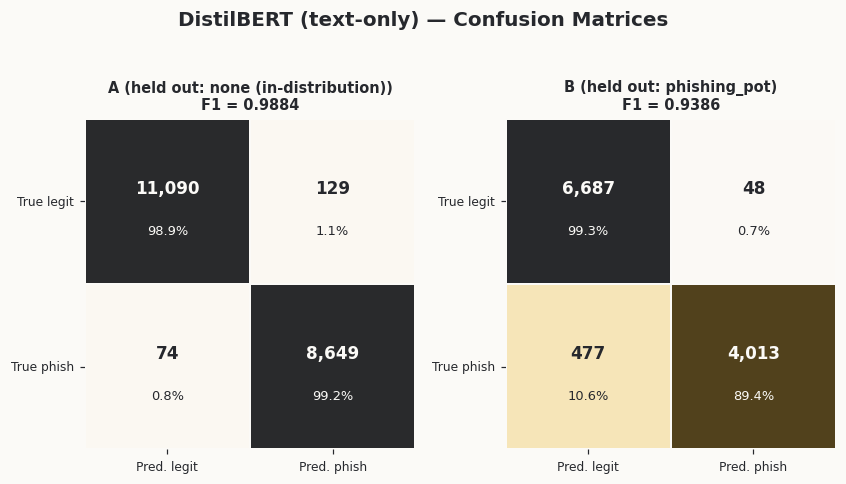

In [17]:
# D2 — Confusion matrices, every protocol
def plot_confusions(model_name, fname):
    fig, axes = plt.subplots(1, len(DESIGNS), figsize=(3.9 * len(DESIGNS), 4.2), squeeze=False)
    for ax, d in zip(axes[0], DESIGNS):
        y, p = PREDS[(d, model_name)]
        cm = confusion_matrix(y, (p >= 0.5).astype(int), labels=[0, 1])
        cmn = cm / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cmn, cmap=SEQ_CMAP, vmin=0, vmax=1, cbar=False, linewidths=1.2,
                    linecolor=PAPER, square=True, ax=ax)
        for i in range(2):
            for j in range(2):
                c = PAPER if cmn[i, j] > 0.55 else GRAPHITE
                ax.text(j + .5, i + .42, f'{cm[i, j]:,}', ha='center', va='center', fontsize=11, fontweight='bold', color=c)
                ax.text(j + .5, i + .68, f'{cmn[i, j]:.1%}', ha='center', va='center', fontsize=8.5, color=c)
        ax.set_xticklabels(['Pred. legit', 'Pred. phish'], fontsize=8)
        ax.set_yticklabels(['True legit', 'True phish'], fontsize=8, rotation=0)
        ax.set_title(f"{d} (held out: {HELD[d]})\nF1 = {RESULTS[(d, model_name)]['f1']:.4f}", fontsize=9.5)
    fig.suptitle(f'{model_name} — Confusion Matrices', fontsize=13, fontweight='bold', y=1.04)
    fig.tight_layout()
    savefig(fig, fname)
    plt.show()


plot_confusions(TXT, 'f26_distilbert_confusion_matrices.png')

---
# PART E — EMBEDDING EXTRACTION

A 768-dimensional mean-pooled representation is extracted from each design's own encoder.
The cache is tied to that encoder's fingerprint (its run signature, best epoch and best
validation F1). If an encoder is retrained, stale embeddings from an earlier encoder are
therefore never reused.

In [18]:
# E1 — Embeddings per design (cached, fingerprinted)
def encoder_fingerprint(d):
    st = enc_states[d]
    key = json.dumps({'sig': st['signature'], 'best_epoch': st['best_epoch'],
                      'best_val_f1': round(st['best_val_f1'], 6)}, sort_keys=True)
    return hashlib.md5(key.encode()).hexdigest()


@torch.no_grad()
def extract_embeddings(model, rows, batch=BATCH_SIZE * 4):
    model.to(DEVICE).eval()
    pos = pos_of.loc[rows].to_numpy()
    out = []
    for s in range(0, len(pos), batch):
        p = torch.as_tensor(pos[s:s + batch])
        ids, attn = input_ids[p].long().to(DEVICE), attention_mask[p].long().to(DEVICE)
        with torch.amp.autocast(DEVICE.type, enabled=USE_FP16):
            hidden = model.base_model(input_ids=ids, attention_mask=attn).last_hidden_state.float()
        m = attn.unsqueeze(-1).float()
        out.append(((hidden * m).sum(1) / m.sum(1).clamp(min=1e-9)).cpu().numpy())
    model.cpu()
    return np.concatenate(out).astype(np.float32)


embeddings_by_design, emb_pos_by_design = {}, {}
for d in DESIGNS:
    emb_path, idx_path = OUT_DIR + f'distilbert_embeddings_{d}.npy', OUT_DIR + f'distilbert_embeddings_index_{d}.npy'
    meta_path = OUT_DIR + f'distilbert_embeddings_{d}.json'
    rows = np.unique(np.concatenate([split_arrays[(d, p)][2] for p in PARTS]))
    fp = encoder_fingerprint(d)
    meta = json.load(open(meta_path)) if os.path.exists(meta_path) else {}
    if meta.get('fingerprint') == fp and os.path.exists(emb_path) and set(np.load(idx_path)) >= set(rows):
        emb, emb_idx = np.load(emb_path), np.load(idx_path)
        print(f'{d}: embeddings loaded from cache {emb.shape}')
    else:
        t0 = time.time()
        emb, emb_idx = extract_embeddings(encoders[d], rows), rows
        np.save(emb_path, emb)
        np.save(idx_path, emb_idx)
        json.dump({'fingerprint': fp, 'n': len(rows)}, open(meta_path, 'w'))
        print(f'{d}: extracted {emb.shape} in {time.time() - t0:.0f}s')
    assert emb.shape[1] == EMBED_DIM
    embeddings_by_design[d] = emb
    emb_pos_by_design[d] = pd.Series(np.arange(len(emb_idx)), index=emb_idx)

# Legacy filenames that Phase 3 loads (Split A encoder)
if not QUICK_TEST:
    np.save(OUT_DIR + 'distilbert_embeddings.npy', embeddings_by_design['A'])
    np.save(OUT_DIR + 'distilbert_embeddings_index.npy', np.load(OUT_DIR + 'distilbert_embeddings_index_A.npy'))


def emb_lookup(d, idx):
    return embeddings_by_design[d][emb_pos_by_design[d].loc[idx].to_numpy()]

A: embeddings loaded from cache (99707, 768)
B: embeddings loaded from cache (99707, 768)


---
# PART F — MLP HEADS ON FROZEN EMBEDDINGS

Two heads with an **identical** architecture, optimiser and early-stopping rule are trained on
the same frozen embeddings from each design's encoder:

* **DistilBERT embeddings + MLP (no structural)** takes the 768-dim embedding only. This is the
  "text-only" configuration of the retraining-based ablation.
* **DistilBERT + Structural (Fusion)** takes the 768-dim embedding plus the 13 scaled structural
  features (781-dim).

Reviewer 3 asked whether the ablation's text-only model is the fine-tuned DistilBERT classifier.
It is **not**. DistilBERT (text-only) is the end-to-end fine-tuned classifier with its own linear
head. The ablation's text-only configuration is the embeddings-only MLP. Comparing it with Fusion
isolates the contribution of the structural features, because nothing else differs between the two.

Early stopping for the heads uses each design's grouped validation partition (patience 10,
maximum 100 epochs) and class-weighted cross-entropy.

In [19]:
# F1 — Head definition and training
class MLPHead(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        layers, prev = [], d_in
        for h in HEAD_HIDDEN:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(HEAD_DROPOUT)]
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


@torch.no_grad()
def head_proba(model, X):
    model.eval()
    X = torch.as_tensor(X, device=DEVICE)
    return np.concatenate([torch.softmax(model(X[s:s + 8192]).float(), 1)[:, 1].cpu().numpy()
                           for s in range(0, len(X), 8192)])


def fit_head(Xtr, ytr, Xva, yva, seed):
    set_seed(seed)
    w = torch.tensor([len(ytr) / (2 * max((ytr == 0).sum(), 1)), len(ytr) / (2 * max((ytr == 1).sum(), 1))],
                     dtype=torch.float32, device=DEVICE)
    model = MLPHead(Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=HEAD_LR, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss(weight=w)
    Xt, yt = torch.as_tensor(Xtr, device=DEVICE), torch.as_tensor(ytr, device=DEVICE)
    gen = torch.Generator().manual_seed(seed)
    best_f1, best_state, best_ep, bad = -1.0, None, 0, 0
    for ep in range(HEAD_MAX_EPOCHS):
        model.train()
        perm = torch.randperm(len(yt), generator=gen).to(DEVICE)
        for s in range(0, len(perm), HEAD_BATCH):
            b = perm[s:s + HEAD_BATCH]
            loss = loss_fn(model(Xt[b]), yt[b])
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        f1 = f1_score(yva, (head_proba(model, Xva) >= 0.5).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_ep, bad = f1, ep + 1, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= HEAD_PATIENCE:
                break
    model.load_state_dict(best_state)
    del Xt, yt
    return model, {'best_epoch': best_ep, 'epochs_run': ep + 1, 'best_val_f1': best_f1}


def head_features(d, part, with_struct):
    Xs, y, idx = split_arrays[(d, part)]
    E = emb_lookup(d, idx)
    return (np.hstack([E, Xs]) if with_struct else E).astype(np.float32), y


EMB, FUS = 'DistilBERT embeddings + MLP (no structural)', 'DistilBERT + Structural (Fusion)'
HEADS = {EMB: False, FUS: True}
HEAD_SPEC = {'hidden': list(HEAD_HIDDEN), 'dropout': HEAD_DROPOUT, 'activation': 'ReLU',
             'input_dim': {EMB: EMBED_DIM, FUS: EMBED_DIM + N_STRUCT},
             'load_hint': 'rebuild MLPHead(input_dim) and load_state_dict(torch.load(path)["state_dict"])'}

head_models, head_info = {}, {}
for d in DESIGNS:
    for name, ws in HEADS.items():
        Xtr, ytr = head_features(d, 'train', ws)
        Xva, yva = head_features(d, 'val', ws)
        Xte, yte = head_features(d, 'test', ws)
        t0 = time.time()
        m, info = fit_head(Xtr, ytr, Xva, yva, SEED)
        head_models[(d, name)], head_info[(d, name)] = m.cpu(), {**info, 'seconds': time.time() - t0}
        m.to(DEVICE)
        record(d, name, yte, head_proba(m, Xte))
        m.cpu()
        tag = 'fusion' if ws else 'embonly'
        torch.save({'state_dict': m.state_dict(), 'spec': HEAD_SPEC, 'input_dim': Xtr.shape[1]},
                   MODEL_DIR + f'head_{tag}_{d}.pt')
        del Xtr, Xva, Xte
        gc.collect()
print('\nHead training:', {f'{d}/{"fusion" if HEADS[n] else "embonly"}': f"{v['epochs_run']} ep, {v['seconds']:.1f}s"
                          for (d, n), v in head_info.items()})

  A   DistilBERT embeddings + MLP (no structural)    F1 0.9890  recall 0.9907  AUC 0.9972  FN 81  FP 111
  A   DistilBERT + Structural (Fusion)               F1 0.9892  recall 0.9905  AUC 0.9973  FN 83  FP 105
  B   DistilBERT embeddings + MLP (no structural)    F1 0.9385  recall 0.8958  AUC 0.9946  FN 468  FP 59
  B   DistilBERT + Structural (Fusion)               F1 0.9452  recall 0.9060  AUC 0.9947  FN 422  FP 50

Head training: {'A/embonly': '39 ep, 26.2s', 'A/fusion': '38 ep, 23.2s', 'B/embonly': '23 ep, 14.0s', 'B/fusion': '32 ep, 19.3s'}


---
# PART G — CLASSICAL AND CNN BASELINES ON EVERY PROTOCOL

All baselines are refitted here on every design, so all models share exactly the same partitions.
The classical models use `class_weight='balanced'`, which applies the same weighting formula as
the neural models' class-weighted loss. The CNN is trained by the same `train_classifier` function
as DistilBERT, with the same budget, patience, warmup, clipping and class weights. Only its
learning rate differs, because it is trained from scratch.

Results are cached per design, so a re-run skips finished fits.

In [20]:
# G1 — Classical suite
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

RF_TREES = 300
RF, NB, SVM, LEX, STLEX = ('Structural only (RF)', 'Naive Bayes (TF-IDF)', 'SVM (TF-IDF, linear)',
                           'Lexical only (TF-IDF + LR)', 'Structural + lexical (LR)')
CLASSICAL_KEYS = {RF: 'rf', NB: 'nb', SVM: 'svm', LEX: 'lex', STLEX: 'stlex'}


def texts(rows):
    return df.loc[rows, 'text'].fillna('').str.slice(0, TEXT_CHAR_LIMIT).tolist()


def fit_rf(tr_rows, te_rows, seed):
    raw = lambda r: df.loc[r, EXT_FEATURES].astype('float32').fillna(0).to_numpy()
    rf = RandomForestClassifier(n_estimators=RF_TREES, min_samples_leaf=2, class_weight='balanced',
                                n_jobs=-1, random_state=seed)
    rf.fit(raw(tr_rows), df.loc[tr_rows, 'label'].to_numpy())
    return rf.predict_proba(raw(te_rows))[:, 1]


def fit_classical_suite(tr_rows, te_rows, seed=SEED):
    ytr = df.loc[tr_rows, 'label'].to_numpy()
    out = {RF: fit_rf(tr_rows, te_rows, seed)}
    vec = TfidfVectorizer(**TFIDF_PARAMS)
    Ttr, Tte = vec.fit_transform(texts(tr_rows)), None
    Tte = vec.transform(texts(te_rows))
    lr_kw = dict(C=1.0, max_iter=2000, class_weight='balanced', solver='liblinear')
    out[LEX] = LogisticRegression(**lr_kw).fit(Ttr, ytr).predict_proba(Tte)[:, 1]
    Str, Ste = struct_matrix(tr_rows, tr_rows), struct_matrix(te_rows, tr_rows)
    Htr, Hte = sp.hstack([Ttr, sp.csr_matrix(Str)]).tocsr(), sp.hstack([Tte, sp.csr_matrix(Ste)]).tocsr()
    out[STLEX] = LogisticRegression(**lr_kw).fit(Htr, ytr).predict_proba(Hte)[:, 1]
    out[NB] = MultinomialNB(alpha=0.1).fit(Ttr, ytr).predict_proba(Tte)[:, 1]
    svm = LinearSVC(C=1.0, class_weight='balanced', random_state=seed).fit(Ttr, ytr)
    out[SVM] = 1 / (1 + np.exp(-svm.decision_function(Tte)))
    del vec, Ttr, Tte, Htr, Hte
    gc.collect()
    return {k: np.asarray(v, dtype=np.float32) for k, v in out.items()}


for d in DESIGNS:
    tr_rows, te_rows = split_arrays[(d, 'train')][2], split_arrays[(d, 'test')][2]
    cache = f'{BASE_DIR}classical_{d}.npz'
    probs = None
    if os.path.exists(cache):
        z = np.load(cache, allow_pickle=False)
        if np.array_equal(z['idx'], te_rows) and all(k in z for k in CLASSICAL_KEYS.values()):
            probs = {m: z[k] for m, k in CLASSICAL_KEYS.items()}
            print(f'{d}: classical baselines loaded from cache')
    if probs is None:
        t0 = time.time()
        probs = fit_classical_suite(tr_rows, te_rows)
        np.savez(cache, idx=te_rows, **{CLASSICAL_KEYS[m]: p for m, p in probs.items()})
        print(f'{d}: classical baselines fitted in {time.time() - t0:.0f}s')
    for m, p in probs.items():
        record(d, m, split_arrays[(d, 'test')][1], p)

A: classical baselines loaded from cache
  A   Structural only (RF)                           F1 0.9256  recall 0.9124  AUC 0.9803  FN 764  FP 515
  A   Naive Bayes (TF-IDF)                           F1 0.9613  recall 0.9404  AUC 0.9946  FN 520  FP 141
  A   SVM (TF-IDF, linear)                           F1 0.9857  recall 0.9887  AUC 0.9986  FN 99  FP 151
  A   Lexical only (TF-IDF + LR)                     F1 0.9797  recall 0.9827  AUC 0.9978  FN 151  FP 204
  A   Structural + lexical (LR)                      F1 0.9803  recall 0.9830  AUC 0.9980  FN 148  FP 197
B: classical baselines loaded from cache
  B   Structural only (RF)                           F1 0.9195  recall 0.9067  AUC 0.9743  FN 419  FP 294
  B   Naive Bayes (TF-IDF)                           F1 0.8641  recall 0.7739  AUC 0.9862  FN 1015  FP 78
  B   SVM (TF-IDF, linear)                           F1 0.9188  recall 0.8655  AUC 0.9910  FN 604  FP 83
  B   Lexical only (TF-IDF + LR)                     F1 0.9439  recall 0


  CNN — SPLIT A
  [cnn/A] already finished (8 epochs, best val F1 0.9753).
  [cnn/A] genuine early stopping fired at epoch 5 (final budget 10).
  A   CNN (word-embedding, from scratch)             F1 0.9766  recall 0.9701  AUC 0.9982  FN 261  FP 145

  CNN — SPLIT B
  [cnn/B] already finished (10 epochs, best val F1 0.9799).
  [cnn/B] genuine early stopping fired at epoch 7 (final budget 10).
  B   CNN (word-embedding, from scratch)             F1 0.9189  recall 0.8702  AUC 0.9907  FN 583  FP 107
  figure saved: f25c_cnn_training_curves.png


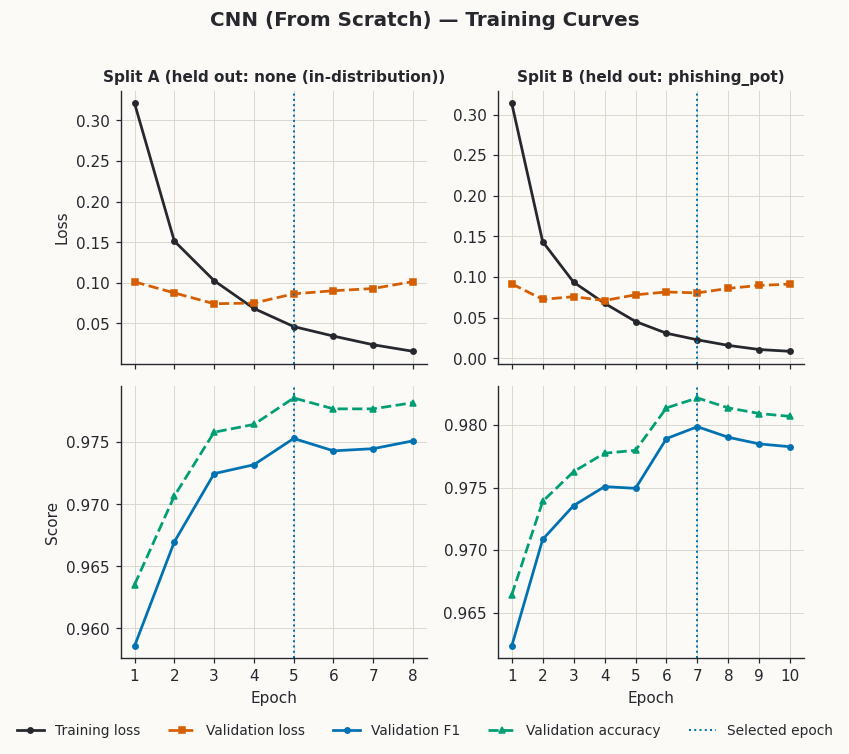

     model design  epochs_run  final_epoch_budget  best_epoch  best_val_f1          stop_reason  epochs_after_best  val_f1_range_last_4_epochs  lr_at_stop
DistilBERT      A           9                   9           6       0.9880 early_stopping_fired                  3                     0.00207    0.000002
DistilBERT      B           6                   6           3       0.9874 early_stopping_fired                  3                     0.00238    0.000009
       CNN      A           8                   8           5       0.9753 early_stopping_fired                  3                     0.00100    0.000222
       CNN      B          10                  10           7       0.9799 early_stopping_fired                  3                     0.00160    0.000000


In [21]:
# G2 — Word-embedding CNN trained from scratch (same trainer/extension logic as DistilBERT)
CNN = 'CNN (word-embedding, from scratch)'


class KimCNN(nn.Module):
    """Kim (2014) CNN over WordPiece ids; embeddings learned from scratch, not pre-trained."""

    def __init__(self, vocab, emb=128, filters=100, sizes=(3, 4, 5), dropout=0.5, pad=0):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=pad)
        self.convs = nn.ModuleList([nn.Conv1d(emb, filters, k) for k in sizes])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(filters * len(sizes), 2)

    def forward(self, input_ids, attention_mask):
        x = self.emb(input_ids).transpose(1, 2)
        m = attention_mask.unsqueeze(1)
        pooled = []
        for conv in self.convs:
            h = torch.relu(conv(x))
            h = h.masked_fill(m[:, :, :h.size(2)] == 0, -1e4)
            pooled.append(h.max(dim=2).values)
        return self.fc(self.drop(torch.cat(pooled, 1)))


def build_cnn():
    return KimCNN(len(tokenizer), pad=tokenizer.pad_token_id)


cnn_models, cnn_states = {}, {}
for d in DESIGNS:
    print(f"\n{'=' * 70}\n  CNN — SPLIT {d}\n{'=' * 70}")
    cnn_models[d], cnn_states[d] = train_until_plateau('cnn', d, build_cnn, CNN_LEARNING_RATE)
    y, p = predict_proba(cnn_models[d], make_loader(d, 'test', BATCH_SIZE * 4, shuffle=False))
    record(d, CNN, y, p)

plot_training_curves(cnn_states, 'CNN (From Scratch) — Training Curves', 'f25c_cnn_training_curves.png')
stop_df = pd.concat([stopping_audit(enc_states, 'DistilBERT'), stopping_audit(cnn_states, 'CNN')],
                    ignore_index=True)
stop_df.to_csv(OUT_DIR + 'table_early_stopping_outcome.csv', index=False)
print(stop_df.to_string(index=False))

---
# PART H — UNIFIED COMPARISON AND GENERALISATION GAP

**Protocols:** A is in-distribution. B withholds `phishing_pot`, whose emails are all phishing, so
source and class are confounded there. C1–C3 each withhold one TREC collection containing both
classes, so their mean ± SD is the unconfounded cross-source estimate.

In [22]:
# H1 — Master table and generalisation gap
# Guard: align DESIGNS/LOSO_DESIGNS with what's actually in RESULTS. This protects against
# Part C's C1 cell having overwritten DESIGNS earlier (e.g. to ['A', 'B'] when run standalone),
# or against C1/C2/C3 simply not having been trained+scored yet in this session.
_scored_designs = sorted({d for (d, m) in RESULTS.keys()})
print('Designs actually present in RESULTS:', _scored_designs)

DESIGNS = [d for d in (globals().get('DESIGNS') or []) if d in _scored_designs] or _scored_designs
LOSO_DESIGNS = [d for d in ['C1', 'C2', 'C3'] if d in _scored_designs]
_missing = [d for d in ['A', 'B', 'C1', 'C2', 'C3'] if d not in _scored_designs]
if _missing:
    print(f'WARNING: no results for {_missing} — not trained/scored in this run. '
          f'Master table will report only on {DESIGNS}.')

MODEL_ORDER = [RF, NB, SVM, LEX, STLEX, CNN, TXT, EMB, FUS]
master_df = pd.DataFrame(list(RESULTS.values()))
master_df['model'] = pd.Categorical(master_df['model'], MODEL_ORDER, ordered=True)
master_df['split'] = pd.Categorical(master_df['split'], DESIGNS, ordered=True)
master_df = master_df[master_df['split'].isin(DESIGNS)]   # drop any stray rows outside DESIGNS
master_df = master_df.sort_values(['split', 'model']).reset_index(drop=True)
master_df.to_csv(OUT_DIR + 'table_master_comparison.csv', index=False)


def pivot(metric):
    return master_df.pivot_table(index='model', columns='split', values=metric,
                                 aggfunc='first', observed=True).reindex(MODEL_ORDER)


pf1, prec, pfn = pivot('f1'), pivot('recall'), pivot('FN')

gap_m = pd.DataFrame(index=MODEL_ORDER)
if 'A' in DESIGNS:
    gap_m['F1 (A)'] = pf1['A']
if 'B' in DESIGNS:
    gap_m['F1 (B)'] = pf1['B']
for c in LOSO_DESIGNS:
    gap_m[f'F1 ({c})'] = pf1[c]
if LOSO_DESIGNS:
    gap_m['LOSO mean'] = pf1[LOSO_DESIGNS].mean(axis=1)
    gap_m['LOSO SD'] = pf1[LOSO_DESIGNS].std(axis=1, ddof=1) if len(LOSO_DESIGNS) > 1 else np.nan
    if 'A' in DESIGNS:
        gap_m['Gap A-LOSO'] = gap_m['F1 (A)'] - gap_m['LOSO mean']
if 'A' in DESIGNS and 'B' in DESIGNS:
    gap_m['Gap A-B'] = gap_m['F1 (A)'] - gap_m['F1 (B)']
gap_m = gap_m.round(4)
print('=== F1 BY PROTOCOL AND GENERALISATION GAP ===\n')
print(gap_m.to_string())
gap_m.to_csv(OUT_DIR + 'table_master_generalisation_gap.csv')

errors_m = pd.concat({'recall': prec.round(4), 'FN': pfn}, axis=1)
errors_m.to_csv(OUT_DIR + 'table_recall_and_false_negatives.csv')
print('\n=== RECALL AND FALSE NEGATIVES BY PROTOCOL ===\n')
print(errors_m.to_string())

# Only compute/print the gap summary if there is a usable gap column at all.
gap_col = None
if LOSO_DESIGNS and 'Gap A-LOSO' in gap_m.columns:
    gap_col = 'Gap A-LOSO'
elif 'Gap A-B' in gap_m.columns:
    gap_col = 'Gap A-B'

if gap_col is not None:
    distilbert_gap, fusion_gap = gap_m.loc[TXT, gap_col], gap_m.loc[FUS, gap_col]
    best_classical_gap = gap_m.loc[[RF, NB, SVM, LEX, STLEX], gap_col].min()
    print(f'\n>> Gap measure: {gap_col}')
    print(f'>> DistilBERT (text-only) {distilbert_gap:.4f} | Fusion {fusion_gap:.4f} | '
          f'smallest classical {best_classical_gap:.4f}')
    cross_col = 'LOSO mean' if (LOSO_DESIGNS and 'LOSO mean' in gap_m.columns) else 'F1 (B)'
    if cross_col in gap_m.columns:
        print(f'>> Smallest gap overall: {gap_m[gap_col].idxmin()} | '
              f'best cross-source mean F1: {gap_m[cross_col].idxmax()}')
else:
    print('\n>> No cross-source design (B or C1-C3) scored yet — generalisation gap not computed. '
          f'Only in-distribution results available for: {DESIGNS}')

Designs actually present in RESULTS: ['A', 'B']
=== F1 BY PROTOCOL AND GENERALISATION GAP ===

                                             F1 (A)  F1 (B)  Gap A-B
Structural only (RF)                         0.9256  0.9195   0.0061
Naive Bayes (TF-IDF)                         0.9613  0.8641   0.0972
SVM (TF-IDF, linear)                         0.9857  0.9188   0.0669
Lexical only (TF-IDF + LR)                   0.9797  0.9439   0.0358
Structural + lexical (LR)                    0.9803  0.9510   0.0293
CNN (word-embedding, from scratch)           0.9766  0.9189   0.0577
DistilBERT (text-only)                       0.9884  0.9386   0.0498
DistilBERT embeddings + MLP (no structural)  0.9890  0.9385   0.0505
DistilBERT + Structural (Fusion)             0.9892  0.9452   0.0441

=== RECALL AND FALSE NEGATIVES BY PROTOCOL ===

                                             recall           FN      
split                                             A       B    A     B
model                   

  figure saved: f27_master_model_comparison.png


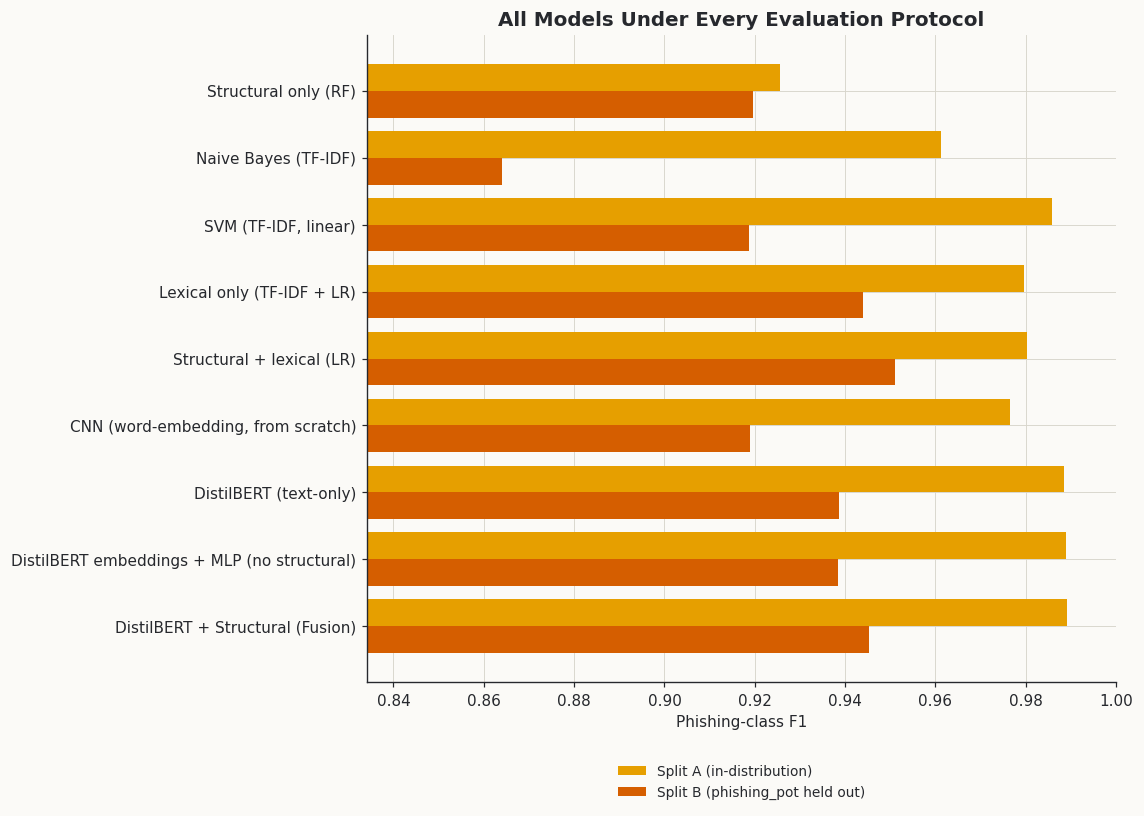

  figure saved: f28_f1_heatmap_all_protocols.png


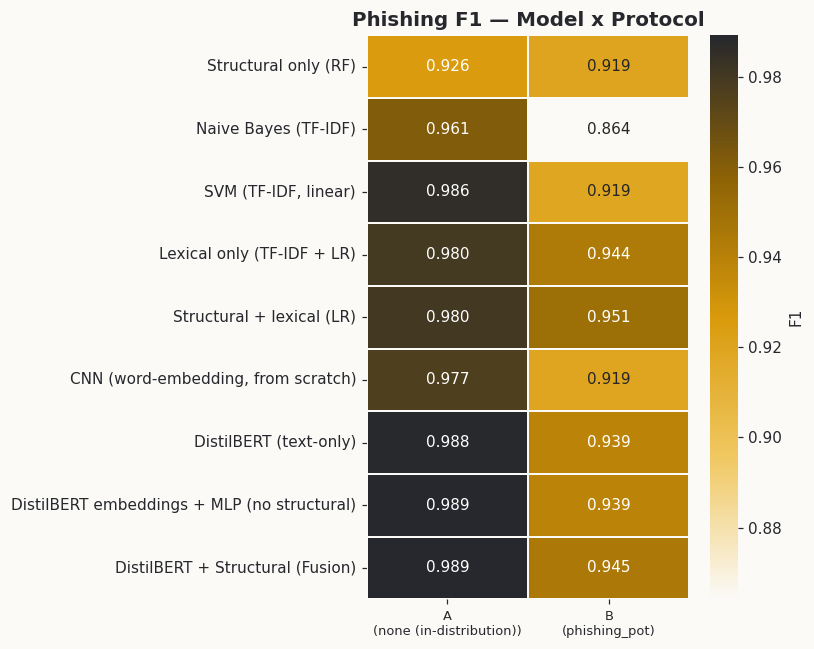

  figure saved: f26b_fusion_confusion_matrices.png


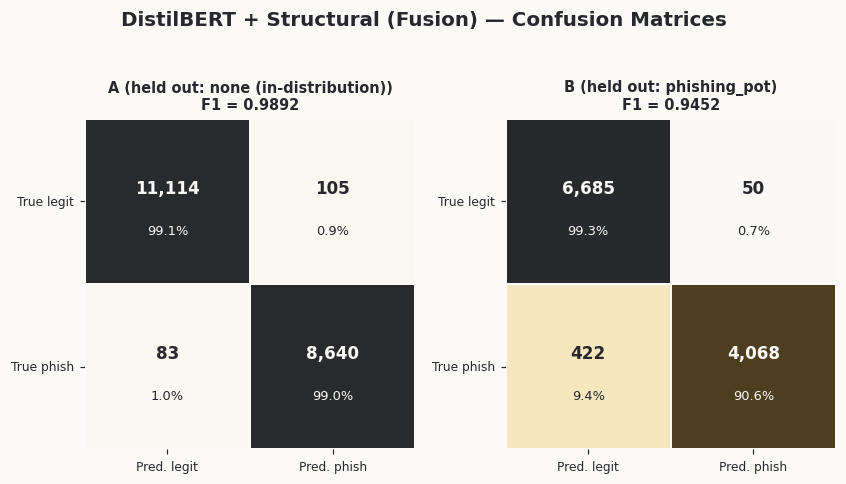

In [23]:
# H2 — Figures
cross_col = 'LOSO mean' if LOSO_DESIGNS else 'F1 (B)'
fig, ax = plt.subplots(figsize=(10.5, 7.5))
y = np.arange(len(MODEL_ORDER))
bars = [('F1 (A)', 'Split A (in-distribution)', DESIGN_COLORS['A'], None)]
if 'B' in DESIGNS:
    bars.append(('F1 (B)', f'Split B ({HELD_OUT_SRC} held out)', DESIGN_COLORS['B'], None))
if LOSO_DESIGNS:
    bars.append(('LOSO mean', f'C1–C3 mean ± SD (one TREC source held out)', '#0072B2', 'LOSO SD'))
h = 0.8 / len(bars)
for i, (col, lab, colr, err) in enumerate(bars):
    ax.barh(y + (i - (len(bars) - 1) / 2) * h, gap_m[col], height=h, color=colr, label=lab,
            xerr=gap_m[err] if err else None, capsize=2.5, error_kw={'lw': 1})
ax.set_yticks(y)
ax.set_yticklabels(MODEL_ORDER)
ax.invert_yaxis()
lo = np.nanmin(gap_m[[b[0] for b in bars]].to_numpy())
ax.set_xlim(max(0, lo - 0.03), 1.0)
ax.set_xlabel('Phishing-class F1')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=1, fontsize=9)
ax.set_title('All Models Under Every Evaluation Protocol', fontsize=13, fontweight='bold')
fig.tight_layout()
savefig(fig, 'f27_master_model_comparison.png')
plt.show()

fig, ax = plt.subplots(figsize=(1.6 * len(DESIGNS) + 4, 6))
sns.heatmap(pf1[DESIGNS], annot=True, fmt='.3f', cmap=SEQ_CMAP, linewidths=1, linecolor=PAPER,
            cbar_kws={'label': 'F1'}, ax=ax)
ax.set_xticklabels([f'{d}\n({HELD[d]})' for d in DESIGNS], rotation=0, fontsize=8.5)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Phishing F1 — Model x Protocol', fontsize=13, fontweight='bold')
fig.tight_layout()
savefig(fig, 'f28_f1_heatmap_all_protocols.png')
plt.show()

plot_confusions(FUS, 'f26b_fusion_confusion_matrices.png')

In [24]:
# H3 — Per-language evaluability on Split A test (proposed model and text-only baseline)
if LANG_COL is None:
    print('No language column; skipping.')
    lang_eval_df = pd.DataFrame()
else:
    counts = df[LANG_COL].value_counts()
    big = set(counts[counts >= 50].index)
    te_idx = split_arrays[('A', 'test')][2]
    lang = df.loc[te_idx, LANG_COL].where(df.loc[te_idx, LANG_COL].isin(big), 'other (pooled)').to_numpy()
    rows = []
    for L in pd.unique(lang):
        m = lang == L
        for name in (TXT, FUS):
            y, p = PREDS[('A', name)]
            yy, pp = y[m], (p[m] >= 0.5).astype(int)
            n_leg, n_ph = int((yy == 0).sum()), int((yy == 1).sum())
            row = {'language': L, 'model': name, 'n_test': int(m.sum()), 'legitimate': n_leg, 'phishing': n_ph,
                   'phishing_detection_rate': (pp[yy == 1] == 1).mean() if n_ph else np.nan,
                   'majority_class_accuracy': max(n_leg, n_ph) / max(m.sum(), 1)}
            if min(n_leg, n_ph) >= 15:
                row.update(evaluable='full metrics', accuracy=accuracy_score(yy, pp),
                           f1=f1_score(yy, pp, zero_division=0))
            else:
                row.update(evaluable='detection rate only', accuracy=np.nan, f1=np.nan)
            rows.append(row)
    lang_eval_df = pd.DataFrame(rows).sort_values(['n_test', 'model'], ascending=[False, True])
    lang_eval_df.to_csv(OUT_DIR + 'table_per_language_evaluation_A.csv', index=False)
    print(lang_eval_df.round(4).to_string(index=False))

      language                            model  n_test  legitimate  phishing  phishing_detection_rate  majority_class_accuracy           evaluable  accuracy     f1
            en           DistilBERT (text-only)   18757       11180      7577                   0.9905                   0.5960        full metrics    0.9897 0.9872
            en DistilBERT + Structural (Fusion)   18757       11180      7577                   0.9897                   0.5960        full metrics    0.9906 0.9884
            de           DistilBERT (text-only)     285          12       273                   1.0000                   0.9579 detection rate only       NaN    NaN
            de DistilBERT + Structural (Fusion)     285          12       273                   0.9963                   0.9579 detection rate only       NaN    NaN
            pt           DistilBERT (text-only)     139           2       137                   1.0000                   0.9856 detection rate only       NaN    NaN
          

---
# PART I — STATISTICAL ROBUSTNESS

Exactly what is replicated, on which data (Reviewers 1 and 3):

| Analysis | Models | Data | What varies |
|---|---|---|---|
| I1 Seed replication | Both MLP heads; RF (when enabled) | **Every protocol** (A, B, C1–C3) test sets | Random seed (5 seeds) |
| I2a Grouped CV | Both MLP heads | Split A **test** pool, which the A encoder never saw | Fold (5, grouped by campaign) |
| I2b Grouped CV | All five classical models | Whole corpus (in-distribution) | Fold (5, grouped by campaign) |
| I3 Bootstrap CIs | All nine models | Every protocol test set | Test resample (1,000) |
| I4 McNemar tests | Paired model comparisons | Every protocol test set | — |
| I5 Encoder seeds (optional) | DistilBERT | Every protocol | Seed (off by default: hours per seed) |

Deterministic models (TF-IDF LR/NB/SVM) give identical results for every seed, so their seed SD is
0 by construction. Cross-validating DistilBERT itself would require 5 additional fine-tunes per
fold, so it is not done. The leave-one-source-out folds (C1–C3) are the cross-source analogue of CV.

In [25]:
# I1 — Seed replication on every protocol, with the complete per-seed table (Reviewer 3)
def fit_svm_seeded(design, seed):
    tr_rows, te_rows = split_arrays[(design, 'train')][2], split_arrays[(design, 'test')][2]
    vec = TfidfVectorizer(**TFIDF_PARAMS)
    Ttr = vec.fit_transform(texts(tr_rows))
    Tte = vec.transform(texts(te_rows))
    svm = LinearSVC(C=1.0, class_weight='balanced', random_state=seed).fit(
        Ttr, df.loc[tr_rows, 'label'].to_numpy())
    prob = (1 / (1 + np.exp(-svm.decision_function(Tte)))).astype(np.float32)
    del vec, Ttr, Tte
    gc.collect()
    return prob


SEED_VARYING = ([EMB, FUS]
                + ([RF] if REPLICATE_RF_ACROSS_SEEDS else [])
                + ([SVM] if REPLICATE_SVM_ACROSS_SEEDS else []))
seed_rows = []
for d in DESIGNS:
    yte = split_arrays[(d, 'test')][1]
    for name, ws in HEADS.items():
        Xtr, ytr = head_features(d, 'train', ws)
        Xva, yva = head_features(d, 'val', ws)
        Xte, _ = head_features(d, 'test', ws)
        for s in HEAD_SEEDS:
            if s == SEED:
                prob = PREDS[(d, name)][1]
            else:
                m, _ = fit_head(Xtr, ytr, Xva, yva, s)
                prob = head_proba(m, Xte)
                del m
            seed_rows.append({'design': d, 'model': name, 'seed': s, 'single_run': False, **score(yte, prob)})
        del Xtr, Xva, Xte
        gc.collect()
    if REPLICATE_RF_ACROSS_SEEDS:
        tr_rows, te_rows = split_arrays[(d, 'train')][2], split_arrays[(d, 'test')][2]
        for s in HEAD_SEEDS:
            prob = PREDS[(d, RF)][1] if s == SEED else fit_rf(tr_rows, te_rows, s)
            seed_rows.append({'design': d, 'model': RF, 'seed': s, 'single_run': False, **score(yte, prob)})
    if REPLICATE_SVM_ACROSS_SEEDS:
        for s in HEAD_SEEDS:
            prob = PREDS[(d, SVM)][1] if s == SEED else fit_svm_seeded(d, s)
            seed_rows.append({'design': d, 'model': SVM, 'seed': s, 'single_run': False, **score(yte, prob)})
    print(f'{d}: seed replication done ({len(SEED_VARYING)}/{len(MODEL_ORDER)} models genuinely re-seeded)')
    for name in MODEL_ORDER:
        if name not in SEED_VARYING:
            for s in HEAD_SEEDS:
                seed_rows.append({'design': d, 'model': name, 'seed': s, 'single_run': True,
                                  **score(yte, PREDS[(d, name)][1])})

seed_df = pd.DataFrame(seed_rows)
seed_df.to_csv(OUT_DIR + 'table_seed_replication_all_seeds.csv', index=False)

seed_wide = seed_df.pivot_table(index=['model', 'design'], columns='seed', values='f1', observed=True)
seed_wide['mean'] = seed_wide.mean(axis=1)
seed_wide['sd'] = seed_wide[HEAD_SEEDS].std(axis=1, ddof=1)
seed_wide = seed_wide.reindex(MODEL_ORDER, level=0).round(4)
seed_wide.to_csv(OUT_DIR + 'table_seed_f1_wide.csv')
print('\n=== F1 FOR EVERY SEED (single-run models repeat one value) ===\n')
print(seed_wide.to_string())
print(f'\n>> Genuinely re-seeded models: {SEED_VARYING} (SD > 0 expected).')
print(f'>> Single-run models (deterministic by construction, SD = 0 correctly): '
      f'{[m for m in MODEL_ORDER if m not in SEED_VARYING]}')

# Is the model ranking the same at every seed? Checked, not asserted.
order_rows = []
for d in DESIGNS:
    ref = seed_df[(seed_df.design == d) & (seed_df.seed == SEED)].sort_values('f1', ascending=False)['model'].tolist()
    for s in HEAD_SEEDS:
        cur = seed_df[(seed_df.design == d) & (seed_df.seed == s)].sort_values('f1', ascending=False)['model'].tolist()
        swaps = [f'{a} <-> {b}' for i, (a, b) in enumerate(zip(ref, cur)) if a != b]
        order_rows.append({'design': d, 'seed': s, 'ordering_identical_to_seed_42': cur == ref,
                           'positions_changed': '; '.join(swaps)})
order_df = pd.DataFrame(order_rows)
order_df.to_csv(OUT_DIR + 'table_seed_ordering_check.csv', index=False)
n_same = int(order_df['ordering_identical_to_seed_42'].sum())
print(f'\n>> Full model ordering identical to seed {SEED} in {n_same}/{len(order_df)} (design, seed) cases.')
if n_same < len(order_df):
    print('>> The ordering is NOT preserved everywhere. Report the changes below rather than claiming it is.')
    print(order_df[~order_df['ordering_identical_to_seed_42']].to_string(index=False))

A: seed replication done (4/9 models genuinely re-seeded)
B: seed replication done (4/9 models genuinely re-seeded)

=== F1 FOR EVERY SEED (single-run models repeat one value) ===

seed                                                    42      43      44      45      46    mean      sd
model                                       design                                                        
Structural only (RF)                        A       0.9256  0.9264  0.9261  0.9256  0.9268  0.9261  0.0005
                                            B       0.9195  0.9191  0.9190  0.9172  0.9194  0.9188  0.0009
Naive Bayes (TF-IDF)                        A       0.9613  0.9613  0.9613  0.9613  0.9613  0.9613  0.0000
                                            B       0.8641  0.8641  0.8641  0.8641  0.8641  0.8641  0.0000
SVM (TF-IDF, linear)                        A       0.9857  0.9857  0.9857  0.9857  0.9857  0.9857  0.0000
                                            B       0.9188  0.9188  0.

In [26]:
# I2 — Grouped cross-validation
cv_rows = []

# (a) Heads on each design's own held-out test pool: that design's own encoder never saw
# these emails, so fitting and scoring heads within this pool involves no encoder leakage.
# Generalised from Split A only to every design in CV_HEAD_DESIGNS (Split B included),
# closing the earlier gap where Split B had no fold-CV table at all.
for d in CV_HEAD_DESIGNS:
    if d not in DESIGNS:
        print(f'{d}: no fusion/head model for this design in this session — skipping its CV.')
        continue
    pool_idx = split_arrays[(d, 'test')][2]
    y_pool, groups = split_arrays[(d, 'test')][1], df.loc[pool_idx, GROUP_COL].to_numpy()
    E_pool, S_pool = emb_lookup(d, pool_idx), split_arrays[(d, 'test')][0]
    outer = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    for k, (tr, te) in enumerate(outer.split(E_pool, y_pool, groups)):
        inner = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
        itr, iva = next(inner.split(tr, y_pool[tr], groups[tr]))
        for name, ws in HEADS.items():
            X = np.hstack([E_pool, S_pool]) if ws else E_pool
            m, _ = fit_head(X[tr][itr], y_pool[tr][itr], X[tr][iva], y_pool[tr][iva], SEED)
            cv_rows.append({'analysis': f'heads, Split {d} test pool', 'model': name, 'fold': k + 1,
                            **score(y_pool[te], head_proba(m, X[te]))})
            del m
    print(f'{d}: head CV done.')

# (b) Classical models on the whole corpus (resumable per fold)
if RUN_CLASSICAL_CV:
    all_rows = df.index.to_numpy()
    if QUICK_TEST:
        all_rows = np.random.default_rng(SEED).choice(all_rows, 2000, replace=False)
    y_all, g_all = df.loc[all_rows, 'label'].to_numpy(), df.loc[all_rows, GROUP_COL].to_numpy()
    for k, (tr, te) in enumerate(StratifiedGroupKFold(CV_FOLDS, shuffle=True, random_state=SEED)
                                 .split(all_rows, y_all, g_all)):
        fold_cache = f'{BASE_DIR}cv_classical_fold{k + 1}.csv'
        if os.path.exists(fold_cache) and not QUICK_TEST:
            cv_rows.extend(pd.read_csv(fold_cache).to_dict('records'))
            print(f'  classical CV fold {k + 1}: loaded from cache')
            continue
        t0 = time.time()
        probs = fit_classical_suite(all_rows[tr], all_rows[te])
        fold = [{'analysis': 'classical, whole corpus', 'model': m, 'fold': k + 1, **score(y_all[te], p)}
                for m, p in probs.items()]
        pd.DataFrame(fold).to_csv(fold_cache, index=False)
        cv_rows.extend(fold)
        print(f'  classical CV fold {k + 1}: {time.time() - t0:.0f}s')

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(OUT_DIR + 'table_cv_all_folds.csv', index=False)
cv_summary = (cv_df.groupby(['analysis', 'model'])[['accuracy', 'precision', 'recall', 'f1', 'macro_f1']]
              .agg(['mean', 'std']).round(4))
cv_summary.to_csv(OUT_DIR + 'table_cv_summary.csv')
print('\n=== GROUPED CROSS-VALIDATION (mean, SD over folds) ===\n')
print(cv_summary.to_string())

cv_order = []
for a, g in cv_df.groupby('analysis'):
    ref = g[g.fold == 1].sort_values('f1', ascending=False)['model'].tolist()
    for k, gf in g.groupby('fold'):
        cv_order.append({'analysis': a, 'fold': k,
                         'ordering_identical_to_fold_1': gf.sort_values('f1', ascending=False)['model'].tolist() == ref})
cv_order_df = pd.DataFrame(cv_order)
print('\nOrdering identical to fold 1:\n', cv_order_df.groupby('analysis')['ordering_identical_to_fold_1']
      .agg(['sum', 'count']).to_string())

A: head CV done.
B: head CV done.

=== GROUPED CROSS-VALIDATION (mean, SD over folds) ===

                                                                     accuracy         precision          recall              f1         macro_f1        
                                                                         mean     std      mean     std    mean     std    mean     std     mean     std
analysis                 model                                                                                                                          
heads, Split A test pool DistilBERT + Structural (Fusion)              0.9898  0.0018    0.9841  0.0021  0.9927  0.0025  0.9883  0.0021   0.9896  0.0019
                         DistilBERT embeddings + MLP (no structural)   0.9886  0.0019    0.9828  0.0024  0.9913  0.0037  0.9870  0.0022   0.9884  0.0019
heads, Split B test pool DistilBERT + Structural (Fusion)              0.9950  0.0009    0.9933  0.0010  0.9942  0.0026  0.9938  0.0011   0.9948

In [27]:
# I3 — Bootstrap 95% confidence intervals and paired differences
def bootstrap(design, B=N_BOOTSTRAP, seed=SEED, pairs=()):
    y = split_arrays[(design, 'test')][1]
    models = [m for m in MODEL_ORDER if (design, m) in PREDS]
    hard = {m: PREDS[(design, m)][1] >= 0.5 for m in models}
    rng = np.random.default_rng(seed)
    f1s = {m: [] for m in models}
    recs = {m: [] for m in models}
    for b0 in range(0, B, 50):
        I = rng.integers(0, len(y), (min(50, B - b0), len(y)))
        yb = y[I] == 1
        for m in models:
            pb = hard[m][I]
            tp, fp, fn = (pb & yb).sum(1), (pb & ~yb).sum(1), (~pb & yb).sum(1)
            f1s[m].append(2 * tp / np.maximum(2 * tp + fp + fn, 1))
            recs[m].append(tp / np.maximum(tp + fn, 1))
    f1s = {m: np.concatenate(v) for m, v in f1s.items()}
    recs = {m: np.concatenate(v) for m, v in recs.items()}
    ci = [{'design': design, 'model': m, 'f1': RESULTS[(design, m)]['f1'],
           'f1_ci_low': np.percentile(f1s[m], 2.5), 'f1_ci_high': np.percentile(f1s[m], 97.5),
           'recall': RESULTS[(design, m)]['recall'],
           'recall_ci_low': np.percentile(recs[m], 2.5), 'recall_ci_high': np.percentile(recs[m], 97.5)}
          for m in models]
    diffs = []
    for a, b in pairs:
        if a in f1s and b in f1s:
            dlt = f1s[a] - f1s[b]
            dr = recs[a] - recs[b]
            diffs.append({'design': design, 'comparison': f'{a} minus {b}',
                          'f1_diff': RESULTS[(design, a)]['f1'] - RESULTS[(design, b)]['f1'],
                          'f1_diff_ci_low': np.percentile(dlt, 2.5), 'f1_diff_ci_high': np.percentile(dlt, 97.5),
                          'recall_diff': RESULTS[(design, a)]['recall'] - RESULTS[(design, b)]['recall'],
                          'recall_diff_ci_low': np.percentile(dr, 2.5), 'recall_diff_ci_high': np.percentile(dr, 97.5)})
    return ci, diffs


PAIRS = [(FUS, EMB), (FUS, TXT), (TXT, LEX), (FUS, STLEX)]
ci_rows, diff_rows = [], []
for d in DESIGNS:
    c, dd = bootstrap(d, pairs=PAIRS)
    ci_rows += c
    diff_rows += dd
ci_df, diff_df = pd.DataFrame(ci_rows).round(4), pd.DataFrame(diff_rows).round(4)
diff_df['f1_diff_excludes_zero'] = (diff_df['f1_diff_ci_low'] > 0) | (diff_df['f1_diff_ci_high'] < 0)
diff_df['recall_diff_excludes_zero'] = (diff_df['recall_diff_ci_low'] > 0) | (diff_df['recall_diff_ci_high'] < 0)
ci_df.to_csv(OUT_DIR + 'table_bootstrap_ci.csv', index=False)
diff_df.to_csv(OUT_DIR + 'table_bootstrap_paired_differences.csv', index=False)
print('=== 95% BOOTSTRAP CIs ===\n')
print(ci_df.to_string(index=False))
print('\n=== PAIRED DIFFERENCES (95% CI) ===\n')
print(diff_df.to_string(index=False))

=== 95% BOOTSTRAP CIs ===

design                                       model     f1  f1_ci_low  f1_ci_high  recall  recall_ci_low  recall_ci_high
     A                        Structural only (RF) 0.9256     0.9220      0.9295  0.9124         0.9066          0.9181
     A                        Naive Bayes (TF-IDF) 0.9613     0.9585      0.9643  0.9404         0.9357          0.9457
     A                        SVM (TF-IDF, linear) 0.9857     0.9839      0.9876  0.9887         0.9862          0.9908
     A                  Lexical only (TF-IDF + LR) 0.9797     0.9776      0.9818  0.9827         0.9799          0.9854
     A                   Structural + lexical (LR) 0.9803     0.9782      0.9823  0.9830         0.9803          0.9855
     A          CNN (word-embedding, from scratch) 0.9766     0.9742      0.9787  0.9701         0.9663          0.9736
     A                      DistilBERT (text-only) 0.9884     0.9868      0.9899  0.9915         0.9895          0.9935
     A Distil

In [28]:
# I4 — Exact McNemar tests on paired predictions
mc_rows = []
for d in DESIGNS:
    y = split_arrays[(d, 'test')][1]
    for a, b in PAIRS:
        ca, cb = (PREDS[(d, a)][1] >= 0.5) == (y == 1), (PREDS[(d, b)][1] >= 0.5) == (y == 1)
        n01, n10 = int((ca & ~cb).sum()), int((~ca & cb).sum())
        p = binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 else 1.0
        mc_rows.append({'design': d, 'comparison': f'{a} vs {b}', f'only_first_correct': n01,
                        'only_second_correct': n10, 'p_value': p})
mc_df = pd.DataFrame(mc_rows)
mc_df['significant_0.05_bonferroni'] = mc_df['p_value'] < 0.05 / len(mc_df)
mc_df.to_csv(OUT_DIR + 'table_mcnemar.csv', index=False)
print(mc_df.to_string(index=False))

design                                                                      comparison  only_first_correct  only_second_correct      p_value  significant_0.05_bonferroni
     A DistilBERT + Structural (Fusion) vs DistilBERT embeddings + MLP (no structural)                  14                   10 5.412562e-01                        False
     A                      DistilBERT + Structural (Fusion) vs DistilBERT (text-only)                  47                   32 1.146604e-01                        False
     A                            DistilBERT (text-only) vs Lexical only (TF-IDF + LR)                 246                   94 7.933982e-17                         True
     A                   DistilBERT + Structural (Fusion) vs Structural + lexical (LR)                 262                  105 1.311014e-16                         True
     B DistilBERT + Structural (Fusion) vs DistilBERT embeddings + MLP (no structural)                  84                   29 2.200773e-07          

In [29]:
# I5 — Optional DistilBERT seed replication (EXTRA_ENCODER_SEEDS in A2)
enc_seed_rows = [{'design': d, 'seed': SEED, **score(*PREDS[(d, TXT)])} for d in DESIGNS]
if not EXTRA_ENCODER_SEEDS:
    print('EXTRA_ENCODER_SEEDS is empty: DistilBERT was fine-tuned once per design (seed 42). '
          'Head and RF seed variance is in I1; test-sample uncertainty for DistilBERT is in I3.')
for s in EXTRA_ENCODER_SEEDS:
    for d in DESIGNS:
        m, _ = train_classifier('distilbert', d, build_distilbert, LEARNING_RATE, seed=s)
        y, p = predict_proba(m, make_loader(d, 'test', BATCH_SIZE * 2, shuffle=False))
        enc_seed_rows.append({'design': d, 'seed': s, **score(y, p)})
        del m
        gc.collect()
enc_seed_df = pd.DataFrame(enc_seed_rows)
enc_seed_df.to_csv(OUT_DIR + 'table_distilbert_encoder_seeds.csv', index=False)
if EXTRA_ENCODER_SEEDS:
    print(enc_seed_df.groupby('design')[['f1', 'recall']].agg(['mean', 'std']).round(4).to_string())

EXTRA_ENCODER_SEEDS is empty: DistilBERT was fine-tuned once per design (seed 42). Head and RF seed variance is in I1; test-sample uncertainty for DistilBERT is in I3.


---
# PART J — OPERATING POINT (VALIDATION DATA ONLY)

The threshold is chosen on each design's own validation partition and then applied, unchanged,
to that design's test set.

design              rule  threshold  precision  recall     f1    fpr  FN  FP
     A      default 0.50       0.50     0.9880  0.9905 0.9892 0.0094  83 105
     A F1-optimal on val       0.44     0.9878  0.9906 0.9892 0.0095  82 107
     A    FPR<=1% on val       0.05     0.9869  0.9911 0.9890 0.0103  78 115
     B      default 0.50       0.50     0.9879  0.9060 0.9452 0.0074 422  50
     B F1-optimal on val       0.29     0.9868  0.9156 0.9499 0.0082 379  55
     B    FPR<=1% on val       0.17     0.9854  0.9200 0.9516 0.0091 359  61
  figure saved: f29_threshold_selection.png


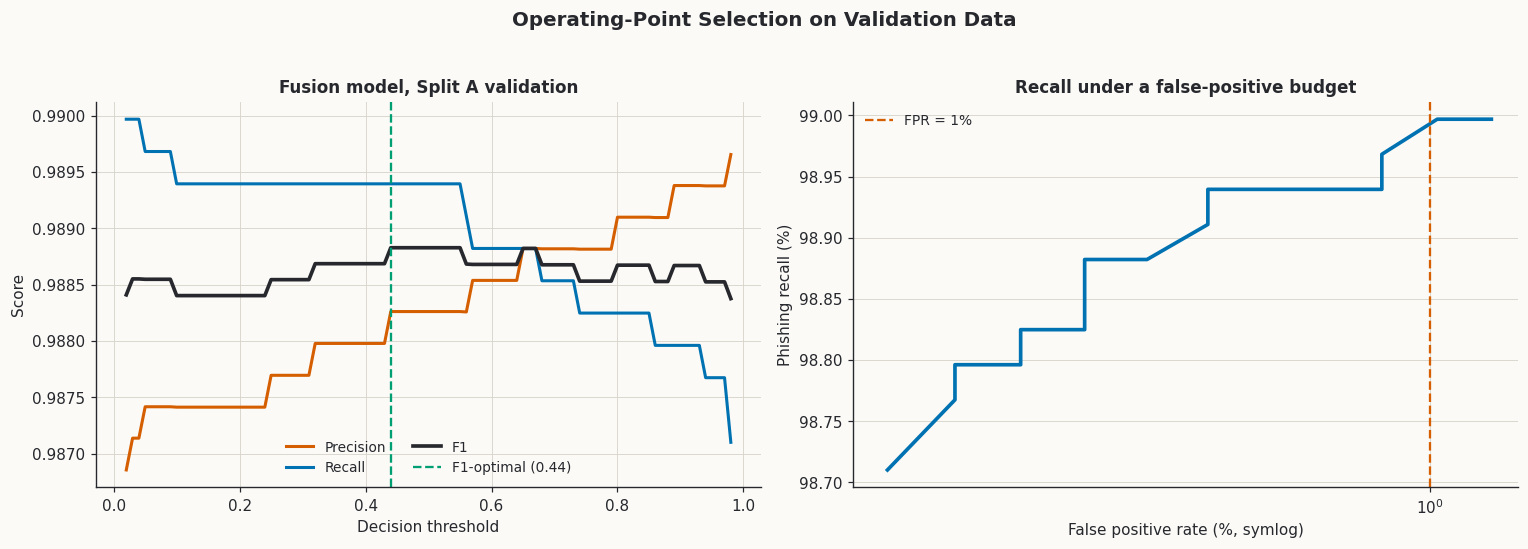

In [30]:
# J1 — Threshold sweep for the proposed fusion model
grid = np.round(np.arange(0.02, 0.99, 0.01), 2)


def sweep_for(y, p):
    rows = []
    for t in grid:
        pr = p >= t
        tp, fp, fn, tn = (pr & (y == 1)).sum(), (pr & (y == 0)).sum(), (~pr & (y == 1)).sum(), (~pr & (y == 0)).sum()
        prec, rec = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
        rows.append({'threshold': t, 'precision': prec, 'recall': rec,
                     'f1': 2 * prec * rec / max(prec + rec, 1e-12), 'fpr': fp / max(fp + tn, 1)})
    return pd.DataFrame(rows)


op_rows, sweeps = [], {}
for d in DESIGNS:
    Xva, yva = head_features(d, 'val', True)
    m = head_models[(d, FUS)].to(DEVICE)
    sw = sweep_for(yva, head_proba(m, Xva))
    m.cpu()
    sweeps[d] = sw
    t_f1 = float(sw.loc[sw['f1'].idxmax(), 'threshold'])
    lowfp = sw[sw['fpr'] <= 0.01]
    t_fp = float(lowfp.loc[lowfp['recall'].idxmax(), 'threshold']) if len(lowfp) else np.nan
    yte, pte = PREDS[(d, FUS)]
    for label, t in [('default 0.50', 0.5), ('F1-optimal on val', t_f1), ('FPR<=1% on val', t_fp)]:
        if not np.isnan(t):
            op_rows.append({'design': d, 'rule': label, 'threshold': t, **score(yte, pte, thr=t)})
op_df = pd.DataFrame(op_rows)
op_df.to_csv(OUT_DIR + 'table_operating_points.csv', index=False)
sweeps['A'].to_csv(OUT_DIR + 'table_phase2_threshold_sweep.csv', index=False)
print(op_df[['design', 'rule', 'threshold', 'precision', 'recall', 'f1', 'fpr', 'FN', 'FP']].round(4).to_string(index=False))

sw = sweeps['A']
PHASE2_BEST_THRESHOLD = float(sw.loc[sw['f1'].idxmax(), 'threshold'])
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
ax.plot(sw['threshold'], sw['precision'], color='#D55E00', lw=2, label='Precision')
ax.plot(sw['threshold'], sw['recall'], color='#0072B2', lw=2, label='Recall')
ax.plot(sw['threshold'], sw['f1'], color=GRAPHITE, lw=2.4, label='F1')
ax.axvline(PHASE2_BEST_THRESHOLD, color='#009E73', ls='--', lw=1.5, label=f'F1-optimal ({PHASE2_BEST_THRESHOLD:.2f})')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Fusion model, Split A validation', fontsize=11)
ax.legend(fontsize=9, loc='lower center', ncol=2)
ax = axes[1]
ax.plot(sw['fpr'] * 100, sw['recall'] * 100, color='#0072B2', lw=2.4)
ax.axvline(1.0, color='#D55E00', ls='--', lw=1.5, label='FPR = 1%')
ax.set_xscale('symlog', linthresh=0.1)
ax.set_xlabel('False positive rate (%, symlog)')
ax.set_ylabel('Phishing recall (%)')
ax.set_title('Recall under a false-positive budget', fontsize=11)
ax.legend(fontsize=9)
fig.suptitle('Operating-Point Selection on Validation Data', fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f29_threshold_selection.png')
plt.show()

---
# PART K — PERSISTENCE, HYPERPARAMETERS, THESIS TABLES, SUMMARY
---

In [31]:
# K1 — Configuration contract for Phase 3 and for the reproducibility appendix (Reviewer 1, comment 5)
phase2_config = {
    **{k: v for k, v in config.items() if k not in ('cleaning_log', 'audit')},
    'phase2_versions': VERSIONS, 'phase2_gpu': GPU_NAME, 'phase2_device': str(DEVICE),
    'phase2_quick_test': QUICK_TEST, 'phase2_seed': SEED,
    'phase2_designs': {d: HELD[d] for d in DESIGNS}, 'phase2_fold_origin': FOLD_ORIGIN,
    'phase2_columns': {'source': SOURCE_COL, 'group': GROUP_COL, 'language': LANG_COL},
    'phase2_struct_scaling': {'transform': STRUCT_TRANSFORM, 'verified_against_phase1': STRUCT_VERIFIED},
    'phase2_rf_features': EXT_FEATURES, 'phase2_class_weights': CLASS_WEIGHTS,
    'phase2_model_checkpoint': MODEL_CHECKPOINT, 'phase2_embed_dim': EMBED_DIM,
    'phase2_max_len': MAX_LEN,
    # Epoch budget is adaptive (Reviewer 1, comment 4), not fixed, so the config records the
    # RULE plus the ACTUAL outcome per design, rather than a single misleading number.
    'phase2_training': {
        'epoch_budget_start': EPOCHS, 'epoch_increment': EPOCH_INCREMENT,
        'epoch_ceiling': MAX_EPOCH_CEILING, 'plateau_tolerance': PLATEAU_TOLERANCE,
        'patience': EARLY_STOP_PATIENCE, 'lr': LEARNING_RATE, 'cnn_lr': CNN_LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY, 'warmup_ratio': WARMUP_RATIO,
        'max_grad_norm': MAX_GRAD_NORM, 'batch_size': BATCH_SIZE, 'fp16': USE_FP16,
    },
    'phase2_distilbert_signatures': {d: enc_states[d]['signature'] for d in DESIGNS},
    'phase2_epochs_run': {d: len(enc_states[d]['history']) for d in DESIGNS},
    'phase2_best_val_f1_by_design': {d: float(enc_states[d]['best_val_f1']) for d in DESIGNS},
    'phase2_stop_reason_by_design': {
        d: ('early_stopping_fired' if enc_states[d]['stopped_early']
            else 'empirical_plateau' if enc_states[d].get('plateau_evidence')
            else 'max_ceiling_reached')
        for d in DESIGNS
    },
    'phase2_head_spec': HEAD_SPEC,
    'phase2_head_training': {'lr': HEAD_LR, 'batch': HEAD_BATCH, 'max_epochs': HEAD_MAX_EPOCHS,
                             'patience': HEAD_PATIENCE, 'weight_decay': 1e-4},
    'phase2_tfidf': {k: str(v) for k, v in TFIDF_PARAMS.items()}, 'phase2_text_char_limit': TEXT_CHAR_LIMIT,
    'phase2_head_seeds': HEAD_SEEDS, 'phase2_cv_folds': CV_FOLDS, 'phase2_bootstrap': N_BOOTSTRAP,
    'phase2_classical_cv_run': RUN_CLASSICAL_CV, 'phase2_rf_seed_replicated': REPLICATE_RF_ACROSS_SEEDS,
    'phase2_best_model': FUS, 'phase2_best_threshold': PHASE2_BEST_THRESHOLD,
    'phase2_models_saved': {'distilbert': 'models/distilbert_best_<design>.pt',
                            'fusion_head': 'models/head_fusion_<design>.pt',
                            'embeddings_only_head': 'models/head_embonly_<design>.pt',
                            'cnn': 'models/cnn_best_<design>.pt',
                            'classical_test_probabilities': 'models/baselines/classical_<design>.npz'},
}
with open(OUT_DIR + 'config_phase2.json', 'w') as f:
    json.dump(phase2_config, f, indent=2, default=str)
print('config_phase2.json written')

for d in SAVE_FUSION_ARRAYS_FOR:
    if d in DESIGNS:
        for part in PARTS:
            X, _ = head_features(d, part, True)
            np.save(f'{OUT_DIR}X_fusion_{d}_{part}.npy', X)
            if d not in ('A', 'B'):
                np.save(f'{OUT_DIR}y_{d}_{part}.npy', split_arrays[(d, part)][1])
                np.save(f'{OUT_DIR}idx_{d}_{part}.npy', split_arrays[(d, part)][2])
        gc.collect()
print(f'Fusion arrays saved for {SAVE_FUSION_ARRAYS_FOR}')

config_phase2.json written
Fusion arrays saved for ['A', 'B', 'C1', 'C2', 'C3']


In [32]:
# K2 — Hyperparameter table (Reviewer 4) and thesis tables
hyper = pd.DataFrame([
    ('DistilBERT checkpoint', MODEL_CHECKPOINT),
    ('Parameters per encoder', f"{enc_states['A']['n_params'] / 1e6:.1f}M"),
    ('Max sequence length', MAX_LEN),
    ('Batch size', BATCH_SIZE),
    ('Epoch budget policy',
     f'starts at {EPOCHS}, extends by {EPOCH_INCREMENT} (ceiling {MAX_EPOCH_CEILING}) unless '
     f'early stopping fires (patience {EARLY_STOP_PATIENCE} on validation F1) or validation F1 '
     f'plateaus (range < {PLATEAU_TOLERANCE} over the last {EARLY_STOP_PATIENCE + 1} epochs)'),
    (f"Epochs run ({', '.join(DESIGNS)})",
     ', '.join(str(len(enc_states[d]['history'])) for d in DESIGNS)),
    (f"Stop reason ({', '.join(DESIGNS)})",
     ', '.join(('early_stop' if enc_states[d]['stopped_early']
                else 'plateau' if enc_states[d].get('plateau_evidence')
                else 'ceiling') for d in DESIGNS)),
    ('Optimiser', 'AdamW (decoupled weight decay)'),
    ('Learning rate (DistilBERT / CNN)', f'{LEARNING_RATE} / {CNN_LEARNING_RATE}'),
    ('Weight decay', WEIGHT_DECAY),
    ('LR schedule', f'linear warmup over {WARMUP_RATIO:.0%} of steps, then linear decay to zero'),
    ('Gradient clipping', f'max norm {MAX_GRAD_NORM}'),
    ('Mixed precision', 'fp16' if USE_FP16 else 'off'),
    ('Loss', 'cross-entropy, class weights n/(2 n_c) from each design\'s training partition'),
    ('Imbalance handling', 'class weighting only; no oversampling, undersampling or synthetic data'),
    ('Embedding pooling', 'mean over non-padding tokens of the final layer'),
    ('MLP heads', f'{HEAD_HIDDEN} ReLU, dropout {HEAD_DROPOUT}, AdamW lr {HEAD_LR}, batch {HEAD_BATCH}, '
                  f'early stopping patience {HEAD_PATIENCE} (max {HEAD_MAX_EPOCHS})'),
    ('CNN', 'embedding 128 (from scratch), filters 3/4/5 x 100, max-pool, dropout 0.5, '
            'same adaptive epoch-budget policy as DistilBERT'),
    ('TF-IDF', f"{TFIDF_PARAMS['ngram_range'][0]}-{TFIDF_PARAMS['ngram_range'][1]} grams, "
               f"max {TFIDF_PARAMS['max_features']:,} features, min_df {TFIDF_PARAMS['min_df']}, "
               f"max_df {TFIDF_PARAMS['max_df']}, sublinear tf, first {TEXT_CHAR_LIMIT:,} characters"),
    ('Logistic regression / SVM', 'C = 1.0, class_weight balanced'),
    ('Naive Bayes', 'multinomial, alpha 0.1'),
    ('Random forest', f'{RF_TREES} trees, min_samples_leaf 2, class_weight balanced, {len(EXT_FEATURES)} features'),
    ('Classical grouped CV (whole corpus)',
     'run' if RUN_CLASSICAL_CV else
     'not run this revision; stability for classical baselines established instead via '
     '5-seed replication (I1) and grouped CV of the neural heads on the Split A test pool (I2a)'),
    ('Random forest, seed replication',
     'refit per seed (5 seeds)' if REPLICATE_RF_ACROSS_SEEDS else
     'single seed only; RF is the weakest/least novel baseline, seed variance reported only '
     'for the proposed embeddings-only and fusion heads'),
    ('Seeds', ', '.join(map(str, HEAD_SEEDS))),
    ('Hardware', f'{GPU_NAME}'),
    ('Software', ', '.join(f'{k} {v}' for k, v in VERSIONS.items())),
], columns=['Setting', 'Value'])
print(hyper.to_string(index=False))


def export_table(name, frame, caption, index=True):
    frame.to_csv(f'{TABLE_DIR}{name}.csv', index=index)
    try:
        txt = frame.to_markdown(index=index)
    except Exception:
        txt = frame.to_string(index=index)
    with open(f'{TABLE_DIR}{name}.md', 'w') as fh:
        fh.write(f'**{caption}**\n\n{txt}\n')
    print(f'  {name:<40} {frame.shape[0]:>4} rows')


print('\nExporting thesis tables ->', TABLE_DIR)
export_table('T10_split_integrity', pd.DataFrame(audit_rows), 'Partition sizes and integrity audit per design', False)
export_table('T10b_heldout_source_confound', confound_df, 'Class composition of each held-out source', False)
export_table('T11_master_model_comparison',
             master_df[['split', 'held_out', 'model', 'accuracy', 'precision', 'recall', 'f1', 'macro_f1',
                        'auc', 'fpr', 'TN', 'FP', 'FN', 'TP']].round(4),
             'All models under every evaluation protocol', False)
export_table('T12_generalisation_gap', gap_m, 'F1 by protocol and generalisation gap')
export_table('T12b_recall_false_negatives', errors_m, 'Recall and false negatives by protocol')
export_table('T13_training_history', hist_df.round(4), 'DistilBERT epoch-by-epoch history', False)
export_table('T13b_hyperparameters', hyper, 'Complete training configuration', False)
export_table('T13c_early_stopping', stop_df, 'Early-stopping outcome per model and design', False)
export_table('T14_seed_replication_all_seeds', seed_df.round(4), 'Every seed, every model, every protocol', False)
export_table('T14b_seed_f1_wide', seed_wide, 'F1 per seed with mean and SD')
export_table('T14c_seed_ordering', order_df, 'Model ordering check across seeds', False)
export_table('T15_cv_folds', cv_df.round(4), 'Grouped cross-validation, every fold', False)
export_table('T15b_cv_summary', cv_summary, 'Grouped cross-validation summary')
export_table('T16_bootstrap_ci', ci_df, '95% bootstrap confidence intervals', False)
export_table('T16b_paired_differences', diff_df, 'Paired bootstrap differences', False)
export_table('T17_mcnemar', mc_df.round(5), 'Exact McNemar tests', False)
export_table('T18_operating_points', op_df.round(4), 'Operating points chosen on validation data', False)
if len(lang_cov_df):
    export_table('T19_tokenizer_language_coverage', lang_cov_df, 'Tokenizer behaviour by language', False)
if len(lang_eval_df):
    export_table('T19b_per_language_evaluation', lang_eval_df.round(4), 'Per-language evaluability, Split A', False)

                            Setting                                                                                                                                                                      Value
              DistilBERT checkpoint                                                                                                                                                    distilbert-base-uncased
             Parameters per encoder                                                                                                                                                                      67.0M
                Max sequence length                                                                                                                                                                        256
                         Batch size                                                                                                                                         

In [33]:
# K3 — Summary
line = '=' * 78
print(line + '\n  PHASE 2 COMPLETE' + (' — QUICK TEST (numbers are NOT reportable)' if QUICK_TEST else '') + '\n' + line)
print(f'\nDesigns: ' + ', '.join(f'{d} (held out: {HELD[d]})' for d in DESIGNS))
print('\nHeld-out source class composition:')
print(confound_df.to_string(index=False))
print('\nEarly stopping / plateau outcome:')
print(stop_df[['model', 'design', 'epochs_run', 'best_epoch', 'stop_reason']].to_string(index=False))
print('\nF1 by protocol:')
print(gap_m.to_string())
print('\nFusion vs embeddings-only head (isolates structural features), paired bootstrap:')
print(diff_df[diff_df['comparison'].str.startswith(FUS + ' minus ' + EMB)]
      [['design', 'f1_diff', 'f1_diff_ci_low', 'f1_diff_ci_high', 'recall_diff',
        'recall_diff_ci_low', 'recall_diff_ci_high']].to_string(index=False))
print(f'\nSeed ordering identical in {n_same}/{len(order_df)} (design, seed) cases')
print(f'Operating point (Fusion, Split A validation): {PHASE2_BEST_THRESHOLD:.2f}')
print(f'\nOutputs: {OUT_DIR}\n         {TABLE_DIR}\n         {FIG_DIR}\n' + line)

  PHASE 2 COMPLETE

Designs: A (held out: none (in-distribution)), B (held out: phishing_pot)

Held-out source class composition:
design held_out_source     n  legitimate  phishing  source_class_confounded
     B    phishing_pot  4490           0      4490                     True
    C1           trec5 43242       26394     16848                    False
    C2           trec6 13912       11087      2825                    False
    C3           trec7 38063       18614     19449                    False

Early stopping / plateau outcome:
     model design  epochs_run  best_epoch          stop_reason
DistilBERT      A           9           6 early_stopping_fired
DistilBERT      B           6           3 early_stopping_fired
       CNN      A           8           5 early_stopping_fired
       CNN      B          10           7 early_stopping_fired

F1 by protocol:
                                             F1 (A)  F1 (B)  Gap A-B
Structural only (RF)                         0.9256  0